# Phase 1: Exploratory Data Analysis

**Project:** MarketPulse Ghana
**Data source:** `raw_wfp_prices` table in `agri_ghana.duckdb` (WFP Ghana food prices, loaded from HDX without modification)

## Purpose
This notebook examines the raw price data before any cleaning or modelling takes place. Its goal is to understand the structure, quality, coverage and behaviour of the data so that the preprocessing decisions in Phase 2 are based on evidence.

The notebook opens the database in read-only mode. It does not modify, filter or remove any records.

## Contents
| Section | Topic | Question addressed |
|---|---|---|
| 1 | Data overview | What does the table contain (size, column types, time span)? |
| 2 | Cardinality and series inventory | Which price series (commodity, unit and price type) are available? |
| 3 | Data quality | Are there missing, blank or invalid values? |
| 4 | Duplicates and consistency | Are records unique, and are identifiers and currency values consistent? |
| 5 | Coverage | For which markets and periods is data available, and where are the gaps? |
| 6 | Descriptive statistics | What are the typical price levels and spreads for each series? |
| 7 | Distributions | How are prices distributed, and is a log transformation appropriate? |
| 8 | Visualisation | What trends, regional differences and seasonal patterns are present? |
| 9 | Outlier detection | Which observations are unusual and may require treatment? |
| 10 | Correlation analysis | Which columns are redundant, and how do prices relate to each other? |
| 11 | Summary of findings | What are the key findings and the decisions required for Phase 2? |

## Important note on units
The `price` column is recorded in different units depending on the commodity and price type (for example KG, 100 KG, 91 KG, Bunch, 100 Tubers). Prices in different units cannot be compared directly. For this reason, all statistics in this notebook are calculated separately for each **series**, defined as a unique combination of commodity, unit and price type.

In [1]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)


def find_database(file_name: str = "agri_ghana.duckdb") -> Path:
    """Locate the database by searching the current folder and its parent folders."""
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / file_name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {file_name}")


DATABASE_PATH = find_database()

# The connection is read-only so that this notebook cannot change the database.
# If a lock error occurs, close any other process that is using the database file.
con = duckdb.connect(str(DATABASE_PATH), read_only=True)
RAW_TABLE = "raw_wfp_prices"


def query(sql: str) -> pd.DataFrame:
    """Run a SQL query against the database and return the result as a DataFrame."""
    return con.sql(sql).df()


print(f"Connected to: {DATABASE_PATH}")

Connected to: c:\Users\qwarm\Desktop\marketpulse-ghana\agri_ghana.duckdb


## 1. Data Overview
This section confirms the size of the table, the data type of each column and the period covered.

In [2]:
schema = query(f"DESCRIBE {RAW_TABLE}")
COLUMNS = schema["column_name"].tolist()
schema[["column_name", "column_type", "null"]]

,column_name,column_type,null
0,date,DATE,YES
1,admin1,VARCHAR,YES
2,admin2,VARCHAR,YES
3,market,VARCHAR,YES
4,market_id,BIGINT,YES
5,latitude,DOUBLE,YES
6,longitude,DOUBLE,YES
7,category,VARCHAR,YES
8,commodity,VARCHAR,YES
9,commodity_id,BIGINT,YES


In [3]:
overview = query(f"""
    SELECT
        COUNT(*)                                       AS row_count,
        MIN(date)                                      AS first_date,
        MAX(date)                                      AS last_date,
        COUNT(DISTINCT date)                           AS months_with_data,
        date_diff('month', MIN(date), MAX(date)) + 1   AS months_in_period
    FROM {RAW_TABLE}
""")
overview

,row_count,first_date,last_date,months_with_data,months_in_period
0,37765,2006-01-15,2023-07-15,211,211


In [4]:
# A random sample of rows. A fixed seed makes the sample reproducible.
query(f"SELECT * FROM {RAW_TABLE} USING SAMPLE reservoir(10 ROWS) REPEATABLE (42)")

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2009-03-15,EASTERN,NEW JUABEN MUNICIPAL,Koforidua,212,6.08,-0.25,cereals and tubers,Rice (local),71,50 KG,actual,Wholesale,GHS,70.00,5.00
1,2013-11-15,GREATER ACCRA,ACCRA METROPOLIS,Accra,209,5.55,-0.22,cereals and tubers,Sorghum,65,109 KG,actual,Wholesale,GHS,163.25,73.21
2,2020-05-15,VOLTA,HOHOE MUNICIPAL,Hohoe,2802,7.15,0.47,cereals and tubers,Cassava,68,KG,aggregate,Retail,GHS,1.80,0.32
3,2020-10-15,EASTERN,NEW JUABEN MUNICIPAL,Koforidua,212,6.08,-0.25,vegetables and fruits,Peppers (fresh),713,KG,aggregate,Retail,GHS,1.97,0.34
4,2021-04-15,BRONG AHAFO,KINTAMPO NORTH,Kintampo,1726,8.06,-1.73,cereals and tubers,Sorghum,65,KG,aggregate,Retail,GHS,2.65,0.46
5,2021-09-15,EASTERN,NEW JUABEN MUNICIPAL,Koforidua,212,6.08,-0.25,vegetables and fruits,Plantains (apem),705,Bunch,aggregate,Wholesale,GHS,45.38,7.65
6,2022-03-15,NORTHERN,TAMALE NORTH SUB METRO,Tamale,220,9.40,-0.83,vegetables and fruits,Tomatoes (navrongo),710,52 KG,aggregate,Wholesale,GHS,33.33,4.76
7,2022-11-15,CENTRAL,CAPE COAST METRO,Cape Coast,213,5.11,-1.24,cereals and tubers,Millet,73,KG,aggregate,Retail,GHS,12.50,0.89
8,2023-01-15,VOLTA,NKWANTA SOUTH,Nkwanta,1733,8.26,0.52,cereals and tubers,Millet,73,93 KG,aggregate,Wholesale,GHS,890.99,77.48
9,2023-04-15,NORTHERN,TAMALE NORTH SUB METRO,Tamale,220,9.40,-0.83,"meat, fish and eggs",Eggs,92,30 pcs,aggregate,Wholesale,GHS,393.10,34.38


In [5]:
# Structural checks:
# - HDX files include a second header row of HXL tags (for example "#date").
#   If this row was loaded as data, it would appear as text beginning with "#".
# - WFP records monthly prices on the 15th of each month. Any other day would be unexpected.
query(f"""
    SELECT
        COUNT(*) FILTER (WHERE admin1 LIKE '#%' OR market LIKE '#%' OR commodity LIKE '#%') AS hxl_header_rows,
        COUNT(*) FILTER (WHERE day(date) <> 15)                                            AS rows_not_on_15th
    FROM {RAW_TABLE}
""")

,hxl_header_rows,rows_not_on_15th
0,0,0


**Note:** The project README states that the dataset contains 38,917 rows. The row count above reflects the data actually stored in the database and should be used as the reference from this point onward.

## 2. Cardinality and Series Inventory
This section counts the distinct values in each column and lists every price series in the data.

In [6]:
distinct_counts = query(
    "SELECT " + ", ".join(f'COUNT(DISTINCT "{col}") AS "{col}"' for col in COLUMNS) + f" FROM {RAW_TABLE}"
)
distinct_counts.T.rename(columns={0: "distinct_values"})

,distinct_values
date,211
admin1,10
admin2,42
market,44
market_id,44
latitude,41
longitude,40
category,4
commodity,26
commodity_id,26


In [7]:
# Frequency of each value in the low-cardinality columns
for col in ["admin1", "category", "pricetype", "priceflag", "currency", "unit"]:
    display(query(f"""
        SELECT "{col}",
               COUNT(*) AS row_count,
               ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percent
        FROM {RAW_TABLE}
        GROUP BY 1
        ORDER BY row_count DESC
    """))

,admin1,row_count,percent
0,BRONG AHAFO,7169,18.98
1,ASHANTI,5995,15.87
2,GREATER ACCRA,5168,13.68
3,CENTRAL,3577,9.47
4,NORTHERN,3489,9.24
5,UPPER EAST,3240,8.58
6,VOLTA,2960,7.84
7,WESTERN,2475,6.55
8,UPPER WEST,1941,5.14
9,EASTERN,1751,4.64


,category,row_count,percent
0,cereals and tubers,22991,60.88
1,vegetables and fruits,10066,26.65
2,"meat, fish and eggs",2851,7.55
3,pulses and nuts,1857,4.92


,pricetype,row_count,percent
0,Wholesale,23235,61.53
1,Retail,14530,38.47


,priceflag,row_count,percent
0,aggregate,25101,66.47
1,actual,12254,32.45
2,"actual,aggregate",410,1.09


,currency,row_count,percent
0,GHS,37765,100.0


,unit,row_count,percent
0,KG,14530,38.47
1,50 KG,4009,10.62
2,100 KG,3161,8.37
3,Bunch,2753,7.29
4,91 KG,2205,5.84
5,109 KG,2176,5.76
6,100 Tubers,1713,4.54
7,93 KG,1503,3.98
8,250 KG,1140,3.02
9,10 KG,867,2.30


### 2.1 Series Inventory
A series is a unique combination of commodity, unit and price type. Prices are only comparable within the same series.

In [8]:
series_inventory = query(f"""
    SELECT
        pricetype, commodity, unit,
        COUNT(*)                  AS row_count,
        COUNT(DISTINCT market_id) AS market_count,
        MIN(date)                 AS first_date,
        MAX(date)                 AS last_date,
        COUNT(DISTINCT date)      AS months_with_data
    FROM {RAW_TABLE}
    GROUP BY ALL
    ORDER BY pricetype, row_count DESC
""")
series_inventory["series"] = series_inventory["commodity"] + " [" + series_inventory["unit"] + "]"

type_counts = series_inventory["pricetype"].value_counts()
print(f"Total series: {len(series_inventory)} ("
      + ", ".join(f"{name}: {count}" for name, count in type_counts.items()) + ")")
series_inventory

Total series: 49 (Wholesale: 27, Retail: 22)


,pricetype,commodity,unit,row_count,market_count,first_date,last_date,months_with_data,series
0,Retail,Maize,KG,778,20,2019-08-15,2023-07-15,48,Maize [KG]
1,Retail,Millet,KG,772,20,2019-08-15,2023-07-15,48,Millet [KG]
2,Retail,Plantains (apentu),KG,713,20,2019-08-15,2023-07-15,48,Plantains (apentu) [KG]
3,Retail,Maize (yellow),KG,709,19,2019-08-15,2023-07-15,47,Maize (yellow) [KG]
4,Retail,Gari,KG,709,20,2019-08-15,2023-07-15,48,Gari [KG]
5,Retail,Plantains (apem),KG,707,20,2019-08-15,2023-07-15,48,Plantains (apem) [KG]
6,Retail,Rice (imported),KG,701,20,2019-08-15,2023-07-15,48,Rice (imported) [KG]
7,Retail,Onions,KG,693,20,2019-08-15,2023-07-15,48,Onions [KG]
8,Retail,Yam,KG,693,20,2019-08-15,2023-07-15,48,Yam [KG]
9,Retail,Yam (puna),KG,678,20,2019-08-15,2023-07-15,48,Yam (puna) [KG]


In [9]:
# Commodities recorded in more than one unit under the same price type
units_per_commodity = (
    series_inventory.groupby(["pricetype", "commodity"])["unit"]
    .agg(unit_count="nunique", units=lambda units: ", ".join(sorted(units)))
)
units_per_commodity[units_per_commodity["unit_count"] > 1]

unit_count               units
pricetype commodity                                   
Wholesale Rice (local)           2       100 KG, 50 KG
          Yam                    2  100 Tubers, 250 KG

In [10]:
# Markets in each region
query(f"""
    SELECT
        admin1                                              AS region,
        COUNT(DISTINCT market_id)                           AS market_count,
        string_agg(DISTINCT market, ', ' ORDER BY market)   AS markets,
        COUNT(*)                                            AS row_count
    FROM {RAW_TABLE}
    GROUP BY 1
    ORDER BY row_count DESC
""")

,region,market_count,markets,row_count
0,BRONG AHAFO,6,"Badu, Kajeji, Kintampo, Sunyani, Techiman, Yeji",7169
1,ASHANTI,3,"Ejura, Kumasi, Obuasi",5995
2,GREATER ACCRA,2,"Accra, Tema",5168
3,CENTRAL,2,"Cape Coast, Mankessim",3577
4,NORTHERN,10,"Banda, Bimbilla, Bunkprugu, Gushegu, Kpandai, ...",3489
5,UPPER EAST,6,"Bawku, Bolga, Bongo, Funbisi, Garu, Navrongo",3240
6,VOLTA,7,"Dambai, Ho, Hohoe, Kadjebi, Kete Krachi, Kpass...",2960
7,WESTERN,1,Sekondi/Takoradi,2475
8,UPPER WEST,6,"Jirapa, Lawra, Nadowli, Tumu, Wa, Wichau",1941
9,EASTERN,1,Koforidua,1751


## 3. Data Quality
This section checks for missing values, blank text values, and values that fall outside a valid range.

In [11]:
# Missing (NULL) values per column
missing_values = query(" UNION ALL ".join(
    f"SELECT '{col}' AS column_name, COUNT(*) - COUNT(\"{col}\") AS null_count FROM {RAW_TABLE}"
    for col in COLUMNS
))
missing_values["null_percent"] = (100 * missing_values["null_count"] / overview.loc[0, "row_count"]).round(3)

# Blank or whitespace-only values in text columns
text_columns = schema.loc[schema["column_type"] == "VARCHAR", "column_name"].tolist()
blank_values = query(" UNION ALL ".join(
    f"SELECT '{col}' AS column_name, COUNT(*) FILTER (WHERE trim(\"{col}\") = '') AS blank_count FROM {RAW_TABLE}"
    for col in text_columns
))
missing_values.merge(blank_values, on="column_name", how="left")

,column_name,null_count,null_percent,blank_count
0,date,0,0.0,NaN
1,admin1,0,0.0,0.0
2,admin2,0,0.0,0.0
3,market,0,0.0,0.0
4,market_id,0,0.0,NaN
5,latitude,0,0.0,NaN
6,longitude,0,0.0,NaN
7,category,0,0.0,0.0
8,commodity,0,0.0,0.0
9,commodity_id,0,0.0,NaN


In [12]:
# Values outside a valid range.
# Ghana lies approximately between latitude 4.5 and 11.5 and longitude -3.5 and 1.5.
invalid_values = query(f"""
    SELECT
        COUNT(*) FILTER (WHERE price <= 0)                          AS price_zero_or_negative,
        COUNT(*) FILTER (WHERE usdprice <= 0)                       AS usdprice_zero_or_negative,
        COUNT(*) FILTER (WHERE latitude  NOT BETWEEN 4.5 AND 11.5)  AS latitude_outside_ghana,
        COUNT(*) FILTER (WHERE longitude NOT BETWEEN -3.5 AND 1.5)  AS longitude_outside_ghana,
        COUNT(*) FILTER (WHERE date > current_date)                 AS future_dates,
        COUNT(*) FILTER (WHERE currency <> 'GHS')                   AS non_ghs_currency
    FROM {RAW_TABLE}
""")
invalid_values.T.rename(columns={0: "row_count"})

,row_count
price_zero_or_negative,0
usdprice_zero_or_negative,0
latitude_outside_ghana,0
longitude_outside_ghana,0
future_dates,0
non_ghs_currency,0


## 4. Duplicates and Consistency
### 4.1 Exact Duplicate Rows

In [13]:
exact_duplicates = query(f"""
    SELECT (SELECT COUNT(*) FROM {RAW_TABLE})
         - (SELECT COUNT(*) FROM (SELECT DISTINCT * FROM {RAW_TABLE})) AS exact_duplicate_rows
""")
exact_duplicates

,exact_duplicate_rows
0,0


### 4.2 Duplicate Keys
Each combination of date, market, commodity, unit and price type should appear only once. Any combination that appears more than once will need a resolution rule in Phase 2.

In [14]:
RECORD_KEY = "date, market_id, commodity_id, unit, pricetype"
duplicate_keys = query(f"""
    SELECT
        {RECORD_KEY},
        ANY_VALUE(market)                       AS market,
        ANY_VALUE(commodity)                    AS commodity,
        COUNT(*)                                AS row_count,
        COUNT(DISTINCT price)                   AS distinct_prices,
        MIN(price)                              AS min_price,
        MAX(price)                              AS max_price,
        string_agg(DISTINCT priceflag, ' | ')   AS price_flags
    FROM {RAW_TABLE}
    GROUP BY {RECORD_KEY}
    HAVING COUNT(*) > 1
    ORDER BY row_count DESC, date
""")
conflicting_count = int((duplicate_keys["distinct_prices"] > 1).sum())
print(f"Keys with more than one row: {len(duplicate_keys):,}")
print(f"Of which have conflicting prices: {conflicting_count:,}")
duplicate_keys.head(20)

Keys with more than one row: 0
Of which have conflicting prices: 0


,date,market_id,commodity_id,unit,pricetype,market,commodity,row_count,distinct_prices,min_price,max_price,price_flags


### 4.3 Price Flag
According to WFP documentation, `actual` indicates a directly observed price, while `aggregate` indicates a monthly value calculated from several observations (for example, weekly collections). This section checks whether the flag is associated with particular price types or time periods.

In [15]:
query(f"""
    SELECT
        priceflag, pricetype,
        COUNT(*)                    AS row_count,
        COUNT(DISTINCT market_id)   AS market_count,
        COUNT(DISTINCT commodity)   AS commodity_count,
        MIN(date)                   AS first_date,
        MAX(date)                   AS last_date
    FROM {RAW_TABLE}
    GROUP BY ALL
    ORDER BY pricetype, row_count DESC
""")

,priceflag,pricetype,row_count,market_count,commodity_count,first_date,last_date
0,aggregate,Retail,14530,20,22,2019-08-15,2023-07-15
1,actual,Wholesale,12254,43,9,2006-01-15,2020-03-15
2,aggregate,Wholesale,10571,18,24,2019-08-15,2023-07-15
3,"actual,aggregate",Wholesale,410,13,7,2019-08-15,2020-03-15


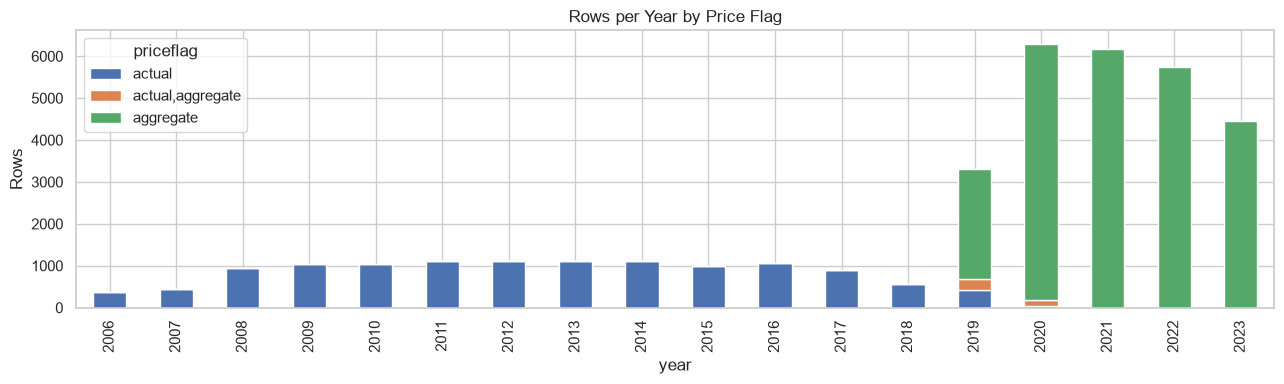

In [16]:
flags_by_year = query(f"SELECT year(date) AS year, priceflag, COUNT(*) AS row_count FROM {RAW_TABLE} GROUP BY ALL")
(flags_by_year.pivot(index="year", columns="priceflag", values="row_count").fillna(0)
    .plot(kind="bar", stacked=True, figsize=(13, 4), title="Rows per Year by Price Flag"))
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

### 4.4 Identifier Consistency
Each identifier should correspond to exactly one name and location, and each name to exactly one identifier. Any violation listed below indicates inconsistent reference data.

In [17]:
consistency_checks = {
    "Market ID linked to more than one market name":
        f"SELECT market_id, string_agg(DISTINCT market, ' | ') AS values_found, COUNT(DISTINCT market) AS n FROM {RAW_TABLE} GROUP BY 1 HAVING n > 1",
    "Market name linked to more than one market ID":
        f"SELECT market, string_agg(DISTINCT market_id::VARCHAR, ' | ') AS values_found, COUNT(DISTINCT market_id) AS n FROM {RAW_TABLE} GROUP BY 1 HAVING n > 1",
    "Market ID linked to more than one region or district":
        f"SELECT market_id, string_agg(DISTINCT admin1 || '/' || admin2, ' | ') AS values_found, COUNT(DISTINCT admin1 || admin2) AS n FROM {RAW_TABLE} GROUP BY 1 HAVING n > 1",
    "Market ID linked to more than one coordinate":
        f"SELECT market_id, string_agg(DISTINCT latitude || ',' || longitude, ' | ') AS values_found, COUNT(DISTINCT (latitude, longitude)) AS n FROM {RAW_TABLE} GROUP BY 1 HAVING n > 1",
    "Coordinate shared by more than one market":
        f"SELECT latitude || ',' || longitude AS coordinate, string_agg(DISTINCT market, ' | ') AS values_found, COUNT(DISTINCT market_id) AS n FROM {RAW_TABLE} GROUP BY 1 HAVING n > 1",
    "Commodity ID linked to more than one commodity name":
        f"SELECT commodity_id, string_agg(DISTINCT commodity, ' | ') AS values_found, COUNT(DISTINCT commodity) AS n FROM {RAW_TABLE} GROUP BY 1 HAVING n > 1",
    "Commodity name linked to more than one commodity ID":
        f"SELECT commodity, string_agg(DISTINCT commodity_id::VARCHAR, ' | ') AS values_found, COUNT(DISTINCT commodity_id) AS n FROM {RAW_TABLE} GROUP BY 1 HAVING n > 1",
    "Commodity linked to more than one category":
        f"SELECT commodity, string_agg(DISTINCT category, ' | ') AS values_found, COUNT(DISTINCT category) AS n FROM {RAW_TABLE} GROUP BY 1 HAVING n > 1",
}

consistency_results = {}
for check_name, sql in consistency_checks.items():
    violations = query(sql)
    consistency_results[check_name] = len(violations)
    status = "PASS" if violations.empty else "FAIL"
    print(f"[{status}] {check_name}: {len(violations)} violation(s)")
    if not violations.empty:
        display(violations.head(10))

[PASS] Market ID linked to more than one market name: 0 violation(s)
[PASS] Market name linked to more than one market ID: 0 violation(s)
[PASS] Market ID linked to more than one region or district: 0 violation(s)
[PASS] Market ID linked to more than one coordinate: 0 violation(s)
[PASS] Coordinate shared by more than one market: 0 violation(s)
[PASS] Commodity ID linked to more than one commodity name: 0 violation(s)
[PASS] Commodity name linked to more than one commodity ID: 0 violation(s)
[PASS] Commodity linked to more than one category: 0 violation(s)


### 4.5 Currency Consistency
`usdprice` should equal `price` divided by the GHS/USD exchange rate for that month. Since all records in a given month should use the same exchange rate, the implied rate (`price / usdprice`) should be nearly constant within each month. Large variation within a month indicates an inconsistency in either `price` or `usdprice`.

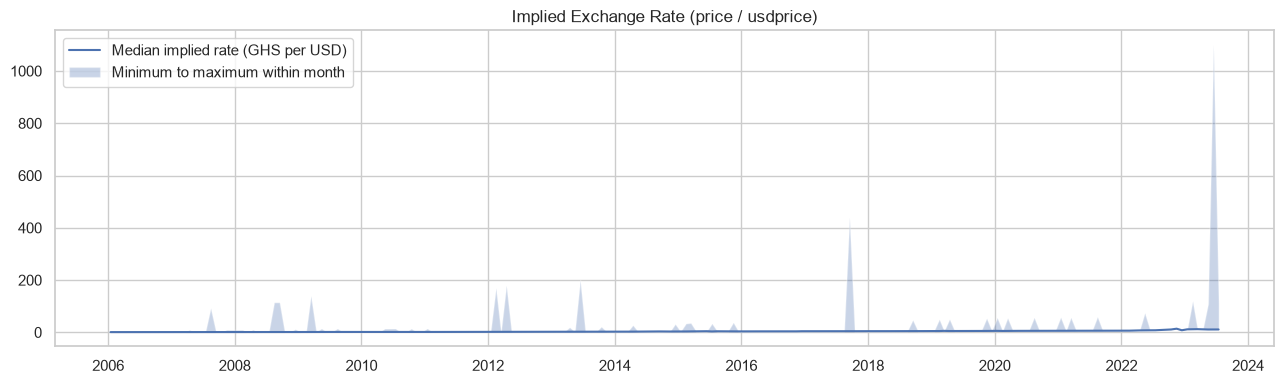

Months with an implied rate spread above 2%: 81 of 211


,date,row_count,rate_min,rate_median,rate_max,spread_percent
209,2023-06-15,588,10.764706,11.000000,1100.000,9902.139037
73,2012-02-15,90,1.697080,1.699972,170.000,9900.335574
32,2008-09-15,77,1.148148,1.149992,115.000,9900.231746
38,2009-03-15,84,1.398026,1.400000,140.000,9900.140977
31,2008-08-15,80,1.148649,1.150000,115.000,9900.120565
89,2013-06-15,92,1.999807,2.000000,200.000,9900.009638
75,2012-04-15,91,1.797386,1.800025,180.000,9900.007502
140,2017-09-15,74,4.395604,4.400069,440.000,9899.944227
19,2007-08-15,36,0.929487,0.930017,93.000,9899.870496
168,2020-01-15,529,5.454545,5.650000,56.502,903.494771


In [18]:
exchange_rates = query(f"""
    SELECT
        date,
        COUNT(*)                    AS row_count,
        MIN(price / usdprice)       AS rate_min,
        MEDIAN(price / usdprice)    AS rate_median,
        MAX(price / usdprice)       AS rate_max
    FROM {RAW_TABLE}
    WHERE usdprice > 0
    GROUP BY 1
    ORDER BY 1
""")
exchange_rates["spread_percent"] = 100 * (exchange_rates["rate_max"] - exchange_rates["rate_min"]) / exchange_rates["rate_median"]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(exchange_rates["date"], exchange_rates["rate_median"], label="Median implied rate (GHS per USD)")
ax.fill_between(exchange_rates["date"], exchange_rates["rate_min"], exchange_rates["rate_max"],
                alpha=0.3, label="Minimum to maximum within month")
ax.set_title("Implied Exchange Rate (price / usdprice)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Months with an implied rate spread above 2%: {(exchange_rates['spread_percent'] > 2).sum()} of {len(exchange_rates)}")
exchange_rates.sort_values("spread_percent", ascending=False).head(10)

In [19]:
# Individual rows whose implied rate differs from the monthly median by more than 2%
inconsistent_usd_rows = query(f"""
    WITH implied AS (
        SELECT *, price / usdprice AS implied_rate FROM {RAW_TABLE} WHERE usdprice > 0
    ),
    monthly AS (
        SELECT date, MEDIAN(implied_rate) AS median_rate FROM implied GROUP BY 1
    )
    SELECT
        i.date, i.market, i.commodity, i.unit, i.pricetype, i.price, i.usdprice,
        ROUND(i.implied_rate, 3)                          AS implied_rate,
        ROUND(m.median_rate, 3)                           AS monthly_median_rate,
        ROUND(100 * (i.implied_rate / m.median_rate - 1), 1) AS deviation_percent
    FROM implied i
    JOIN monthly m USING (date)
    WHERE abs(i.implied_rate / m.median_rate - 1) > 0.02
    ORDER BY abs(i.implied_rate / m.median_rate - 1) DESC
""")
print(f"Rows with an inconsistent USD conversion: {len(inconsistent_usd_rows):,}")
inconsistent_usd_rows.head(15)

Rows with an inconsistent USD conversion: 335


,date,market,commodity,unit,pricetype,price,usdprice,implied_rate,monthly_median_rate,deviation_percent
0,2012-02-15,Wa,Rice (imported),50 KG,Wholesale,170.00,1.0,170.000,1.700,9900.2
1,2008-09-15,Bolga,Yam,100 Tubers,Wholesale,115.00,1.0,115.000,1.150,9900.1
2,2008-08-15,Koforidua,Yam,100 Tubers,Wholesale,115.00,1.0,115.000,1.150,9900.0
3,2013-06-15,Tema,Yam,100 Tubers,Wholesale,400.00,2.0,200.000,2.000,9900.0
4,2009-03-15,Tema,Yam,100 Tubers,Wholesale,140.00,1.0,140.000,1.400,9900.0
5,2023-06-15,Sunyani,Yam,250 KG,Wholesale,1100.00,1.0,1100.000,11.000,9900.0
6,2012-04-15,Ejura,Yam,100 Tubers,Wholesale,180.00,1.0,180.000,1.800,9899.9
7,2017-09-15,Accra,Rice (imported),50 KG,Wholesale,440.00,1.0,440.000,4.400,9899.8
8,2017-09-15,Koforidua,Rice (imported),50 KG,Wholesale,440.00,1.0,440.000,4.400,9899.8
9,2007-08-15,Kumasi,Yam,250 KG,Wholesale,93.00,1.0,93.000,0.930,9899.8


## 5. Coverage
This section shows which markets, commodities and periods are covered. Coverage determines which series have enough history to support reliable analysis and forecasting.

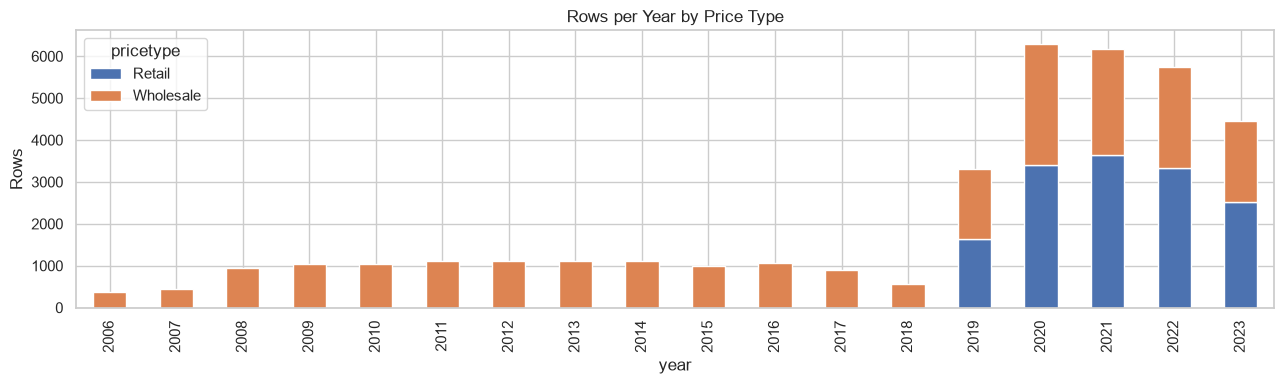

In [20]:
rows_by_year = query(f"SELECT year(date) AS year, pricetype, COUNT(*) AS row_count FROM {RAW_TABLE} GROUP BY ALL ORDER BY year")
(rows_by_year.pivot(index="year", columns="pricetype", values="row_count").fillna(0)
    .plot(kind="bar", stacked=True, figsize=(13, 4), title="Rows per Year by Price Type"))
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

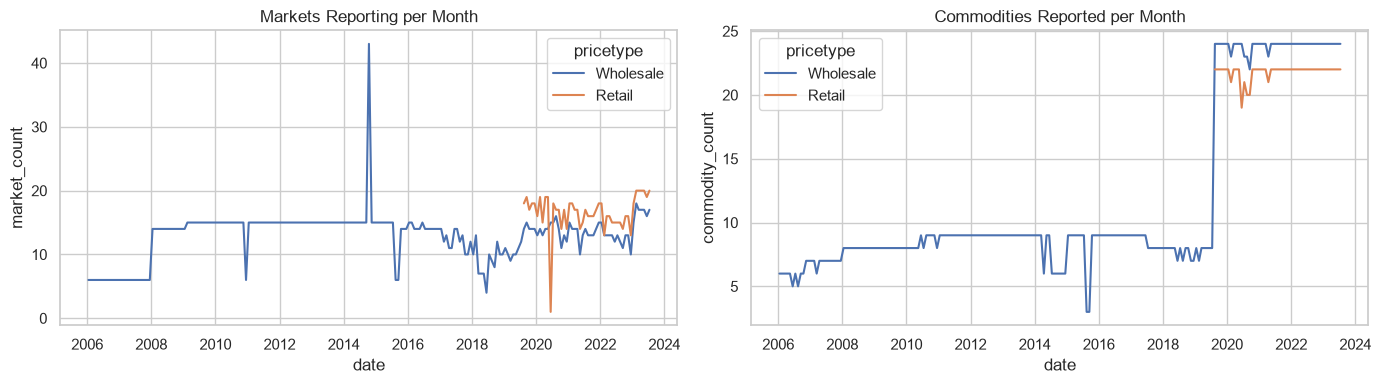

In [21]:
reporting_by_month = query(f"""
    SELECT date, pricetype,
           COUNT(DISTINCT market_id) AS market_count,
           COUNT(DISTINCT commodity) AS commodity_count
    FROM {RAW_TABLE}
    GROUP BY ALL
    ORDER BY date
""")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=reporting_by_month, x="date", y="market_count", hue="pricetype", ax=axes[0])
axes[0].set_title("Markets Reporting per Month")
sns.lineplot(data=reporting_by_month, x="date", y="commodity_count", hue="pricetype", ax=axes[1])
axes[1].set_title("Commodities Reported per Month")
plt.tight_layout()
plt.show()

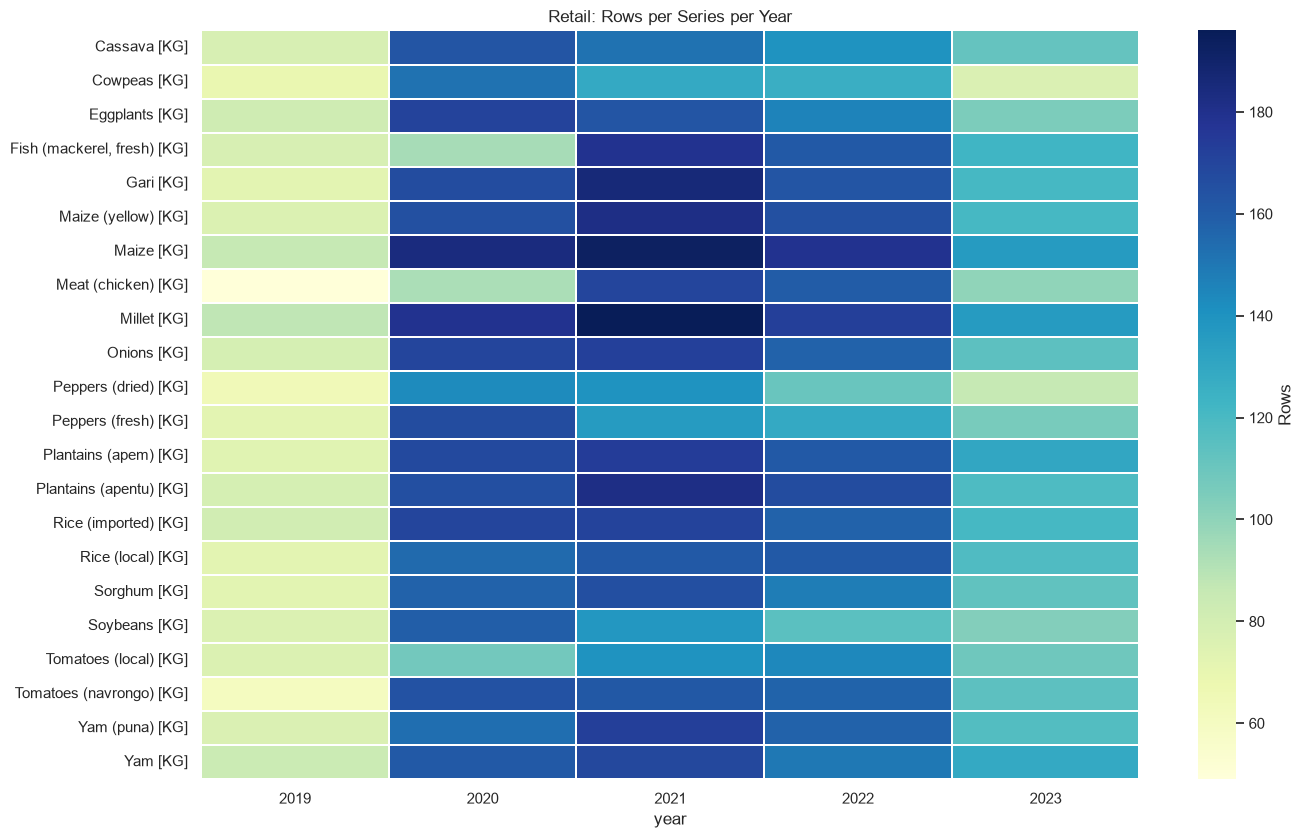

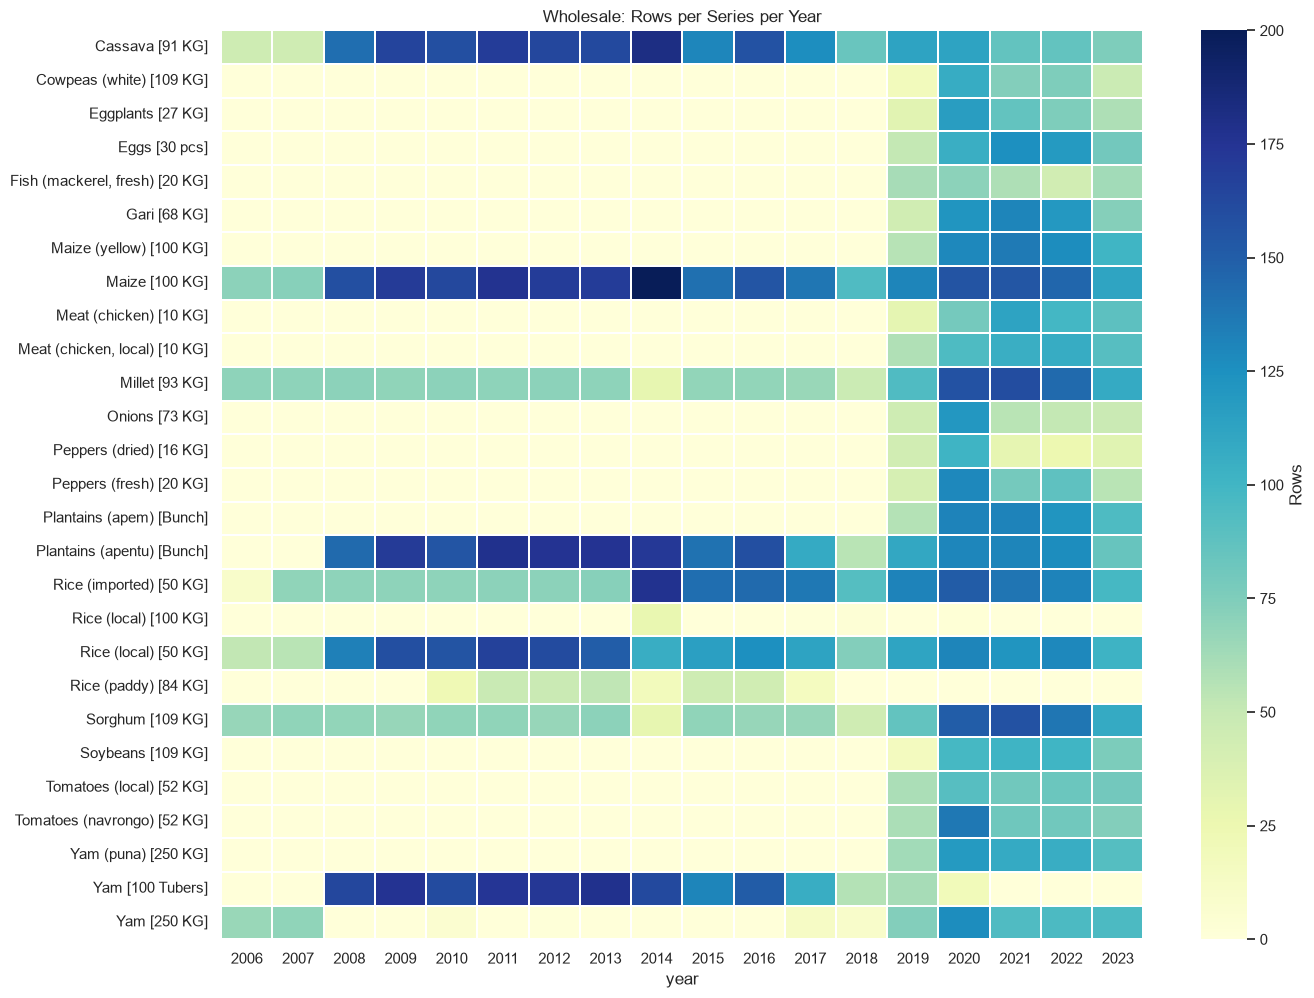

In [22]:
rows_by_series_year = query(f"""
    SELECT pricetype, commodity || ' [' || unit || ']' AS series, year(date) AS year, COUNT(*) AS row_count
    FROM {RAW_TABLE}
    GROUP BY ALL
""")
for price_type, subset in rows_by_series_year.groupby("pricetype"):
    matrix = subset.pivot(index="series", columns="year", values="row_count").fillna(0)
    fig, ax = plt.subplots(figsize=(14, 0.32 * len(matrix) + 1.5))
    sns.heatmap(matrix, cmap="YlGnBu", linewidths=0.3, ax=ax, cbar_kws={"label": "Rows"})
    ax.set_title(f"{price_type}: Rows per Series per Year")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

### 5.1 Completeness of Market-Level Series
For each combination of market, commodity, unit and price type, this section calculates:
- **Completeness:** the number of months with data divided by the number of months between the first and last observation.
- **Longest gap:** the longest run of consecutive months without data.

Market-level series: 980


pricetype                 Retail  Wholesale
months_with_data   count  439.00     541.00
                   mean    33.10      42.95
                   std     11.85      52.77
                   min      1.00       1.00
                   25%     25.00       6.00
                   50%     37.00      26.00
                   75%     43.00      45.00
                   max     47.00     209.00
months_in_period   count  439.00     541.00
                   mean    44.10      58.94
                   std      9.64      63.37
                   min      1.00       1.00
                   25%     46.00      11.00
                   50%     48.00      47.00
                   75%     48.00      48.00
                   max     48.00     211.00
completeness       count  439.00     541.00
                   mean     0.75       0.77
                   std      0.20       0.24
                   min      0.09       0.05
                   25%      0.60       0.57
                   50%      0.81       0.85
                   75%      0.92       1.00
                   max      1.00       1.00
longest_gap_months count  439.00     541.00
                   mean     4.47       8.45
                   std      4.68      14.67
                   min      0.00       0.00
                   25%      1.00       0.00
                   50%      3.00       3.00
                   75%      6.00       9.00
                   max     28.00      93.00

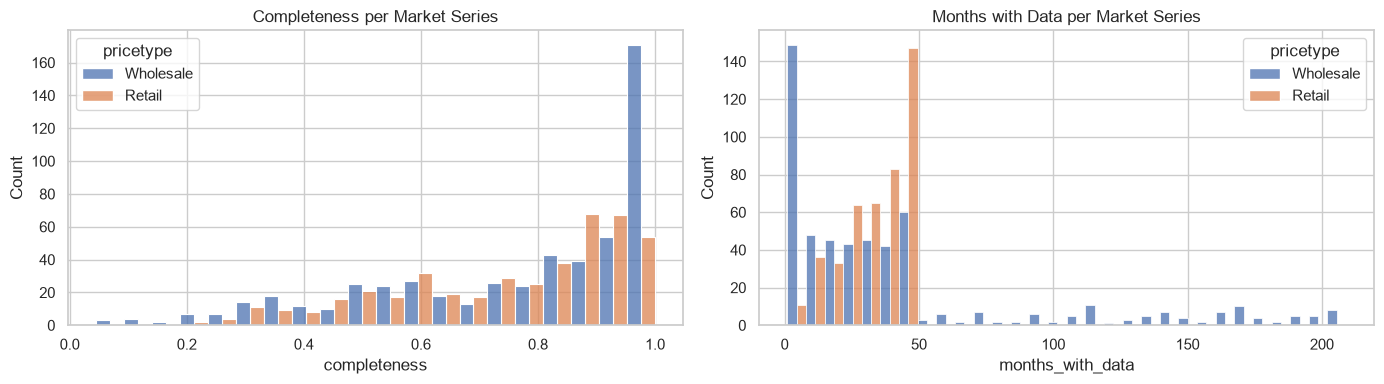

In [23]:
market_series = query(f"""
    WITH observations AS (
        SELECT DISTINCT market_id, market, commodity, unit, pricetype, date FROM {RAW_TABLE}
    ),
    with_gaps AS (
        SELECT *,
               date_diff('month',
                         LAG(date) OVER (PARTITION BY market_id, commodity, unit, pricetype ORDER BY date),
                         date) AS months_since_previous
        FROM observations
    )
    SELECT
        market_id, market, commodity, unit, pricetype,
        COUNT(*)                                        AS months_with_data,
        MIN(date)                                       AS first_date,
        MAX(date)                                       AS last_date,
        date_diff('month', MIN(date), MAX(date)) + 1    AS months_in_period,
        COALESCE(MAX(months_since_previous) - 1, 0)     AS longest_gap_months
    FROM with_gaps
    GROUP BY ALL
""")
market_series["completeness"] = market_series["months_with_data"] / market_series["months_in_period"]

print(f"Market-level series: {len(market_series):,}")
display(market_series.groupby("pricetype")[
    ["months_with_data", "months_in_period", "completeness", "longest_gap_months"]
].describe().T.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=market_series, x="completeness", hue="pricetype", bins=20, multiple="dodge", ax=axes[0])
axes[0].set_title("Completeness per Market Series")
sns.histplot(data=market_series, x="months_with_data", hue="pricetype", bins=30, multiple="dodge", ax=axes[1])
axes[1].set_title("Months with Data per Market Series")
plt.tight_layout()
plt.show()

In [24]:
# Initial criteria for a series to be considered suitable for modelling.
# These thresholds are a starting point and should be reviewed against the results above.
MIN_MONTHS = 36          # at least three years of data
MIN_COMPLETENESS = 0.8   # at least 80% of months present
MAX_GAP_MONTHS = 3       # no gap longer than three months

market_series["meets_criteria"] = (
    (market_series["months_with_data"] >= MIN_MONTHS)
    & (market_series["completeness"] >= MIN_COMPLETENESS)
    & (market_series["longest_gap_months"] <= MAX_GAP_MONTHS)
)
(market_series.groupby(["pricetype", "commodity", "unit"])
    .agg(market_series=("market_id", "count"),
         meeting_criteria=("meets_criteria", "sum"),
         median_months=("months_with_data", "median"),
         median_completeness=("completeness", "median"))
    .sort_values(["pricetype", "meeting_criteria"], ascending=[True, False])
    .round(2))

market_series  meeting_criteria  median_months  median_completeness
pricetype commodity              unit                                                                           
Retail    Maize                  KG                     20                14           43.0                 0.91
          Maize (yellow)         KG                     19                14           43.0                 0.90
          Millet                 KG                     20                13           43.0                 0.91
          Plantains (apentu)     KG                     20                13           43.0                 0.90
          Rice (imported)        KG                     20                13           43.0                 0.90
          Plantains (apem)       KG                     20                12           42.0                 0.90
          Onions                 KG                     20                11           41.0                 0.85
          Cassava                KG                     20                10           37.5                 0.83
          Eggplants              KG                     20                10           37.5                 0.86
          Gari                   KG                     20                10           38.5                 0.89
          Rice (local)           KG                     20                10           35.5                 0.86
          Sorghum                KG                     20                10           38.5                 0.90
          Tomatoes (navrongo)    KG                     20                 9           36.0                 0.81
          Yam                    KG                     20                 9           38.5                 0.82
          Yam (puna)             KG                     20                 9           36.0                 0.82
          Peppers (fresh)        KG                     20                 8           37.0                 0.79
          Peppers (dried)        KG                     20                 6           27.0                 0.66
          Cowpeas                KG                     20                 4           29.5                 0.66
          Soybeans               KG                     20                 3           30.0                 0.68
          Tomatoes (local)       KG                     20                 2           30.5                 0.72
          Meat (chicken)         KG                     20                 1           31.5                 0.73
          Fish (mackerel, fresh) KG                     20                 0           34.0                 0.75
Wholesale Plantains (apem)       Bunch                  17                 9           39.0                 0.92
          Maize (yellow)         100 KG                 17                 8           36.0                 0.89
          Yam                    100 Tubers             15                 7          115.0                 0.90
          Yam (puna)             250 KG                 18                 7           27.0                 0.84
          Eggs                   30 pcs                 18                 6           31.0                 0.77
          Maize                  100 KG                 44                 6            1.0                 1.00
          Plantains (apentu)     Bunch                  19                 6          137.0                 0.83
          Rice (imported)        50 KG                  41                 6            1.0                 1.00
          Tomatoes (navrongo)    52 KG                  17                 6           22.0                 0.81
          Cassava                91 KG                  40                 5            1.0                 1.00
          Gari                   68 KG                  17                 5           30.0                 0.83
          Millet                 93 KG                  18                 5           45.

## 6. Descriptive Statistics
Summary statistics are calculated separately for each series.
- **cv** (coefficient of variation) is the standard deviation divided by the mean. It measures relative spread.
- **max_min_ratio** is the highest price divided by the lowest price.

In [25]:
descriptive_stats = query(f"""
    SELECT
        pricetype, commodity, unit,
        COUNT(*)                                        AS row_count,
        COUNT(DISTINCT market_id)                       AS market_count,
        ROUND(AVG(price), 2)                            AS mean,
        ROUND(MEDIAN(price), 2)                         AS median,
        ROUND(STDDEV_SAMP(price), 2)                    AS std,
        ROUND(STDDEV_SAMP(price) / AVG(price), 2)       AS cv,
        MIN(price)                                      AS min,
        ROUND(quantile_cont(price, 0.01), 2)            AS p01,
        ROUND(quantile_cont(price, 0.25), 2)            AS p25,
        ROUND(quantile_cont(price, 0.75), 2)            AS p75,
        ROUND(quantile_cont(price, 0.99), 2)            AS p99,
        MAX(price)                                      AS max,
        ROUND(MAX(price) / NULLIF(MIN(price), 0), 1)    AS max_min_ratio,
        ROUND(skewness(price), 2)                       AS skewness
    FROM {RAW_TABLE}
    GROUP BY ALL
    ORDER BY pricetype, commodity, unit
""")
descriptive_stats

,pricetype,commodity,unit,row_count,market_count,mean,median,std,cv,min,p01,p25,p75,p99,max,max_min_ratio,skewness
0,Retail,Cassava,KG,645,20,3.14,2.27,2.57,0.82,0.70,0.88,1.46,3.68,13.65,17.69,25.3,2.39
1,Retail,Cowpeas,KG,553,20,6.28,4.64,6.28,1.00,0.43,0.79,2.46,8.34,27.57,81.95,190.6,4.73
2,Retail,Eggplants,KG,667,20,4.72,3.78,3.48,0.74,0.65,0.99,2.11,6.15,15.76,26.08,40.1,1.65
3,Retail,"Fish (mackerel, fresh)",KG,635,20,10.07,8.69,6.40,0.64,1.45,1.62,5.88,12.55,32.58,50.00,34.5,2.07
4,Retail,Gari,KG,709,20,5.95,4.79,3.79,0.64,1.03,1.72,3.77,6.83,24.01,27.78,27.0,2.66
5,Retail,Maize,KG,778,20,3.56,3.00,2.11,0.59,0.78,0.89,1.97,4.77,10.15,12.44,15.9,1.14
6,Retail,Maize (yellow),KG,709,19,3.77,3.20,2.24,0.59,0.73,0.90,2.11,5.03,11.05,12.50,17.1,1.22
7,Retail,Meat (chicken),KG,572,20,9.57,7.78,7.27,0.76,1.18,1.21,4.20,12.74,38.54,44.12,37.4,1.68
8,Retail,Millet,KG,772,20,5.69,4.51,3.20,0.56,1.40,1.65,3.51,7.79,13.89,19.62,14.0,1.14
9,Retail,Onions,KG,693,20,6.62,3.92,8.31,1.26,0.81,1.12,2.62,6.44,44.20,60.00,74.1,3.42


Statistics calculated over the full period combine genuine price variation with general inflation (annual food inflation in Ghana exceeded 50% in late 2022). The table below shows the median price per year, which separates the long-term trend from variation within each year.

In [26]:
yearly_median = query(f"""
    SELECT pricetype, commodity || ' [' || unit || ']' AS series, year(date) AS year,
           MEDIAN(price) AS median_price
    FROM {RAW_TABLE}
    GROUP BY ALL
""")
wholesale_yearly_median = (
    yearly_median[yearly_median["pricetype"] == "Wholesale"]
    .pivot(index="series", columns="year", values="median_price")
)
wholesale_yearly_median.round(1)

year,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
series,,,,,,,,,,,,,,,,,,
Cassava [91 KG],13.0,13.0,16.0,19.6,22.2,23.7,37.1,50.0,40.0,43.4,95.0,89.0,62.9,156.9,201.2,144.5,146.8,773.2
Cowpeas (white) [109 KG],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,138.9,297.3,370.1,461.6,468.8
Eggplants [27 KG],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.8,210.9,266.2,439.7,156.6
Eggs [30 pcs],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,169.0,113.3,424.0,563.4,818.3
"Fish (mackerel, fresh) [20 KG]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,304.2,338.0,229.4,250.0,294.3
Gari [68 KG],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,227.1,236.3,289.3,292.6,456.3
Maize (yellow) [100 KG],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.2,138.5,267.2,366.7,538.5
Maize [100 KG],17.8,21.1,44.0,54.5,45.2,65.0,88.0,74.0,103.1,144.0,144.0,126.2,133.0,131.0,138.2,253.4,354.0,520.2
Meat (chicken) [10 KG],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,188.8,197.5,299.6,271.0,275.9


## 7. Distributions
This section examines the shape of the price distributions and tests whether a log transformation reduces skewness.

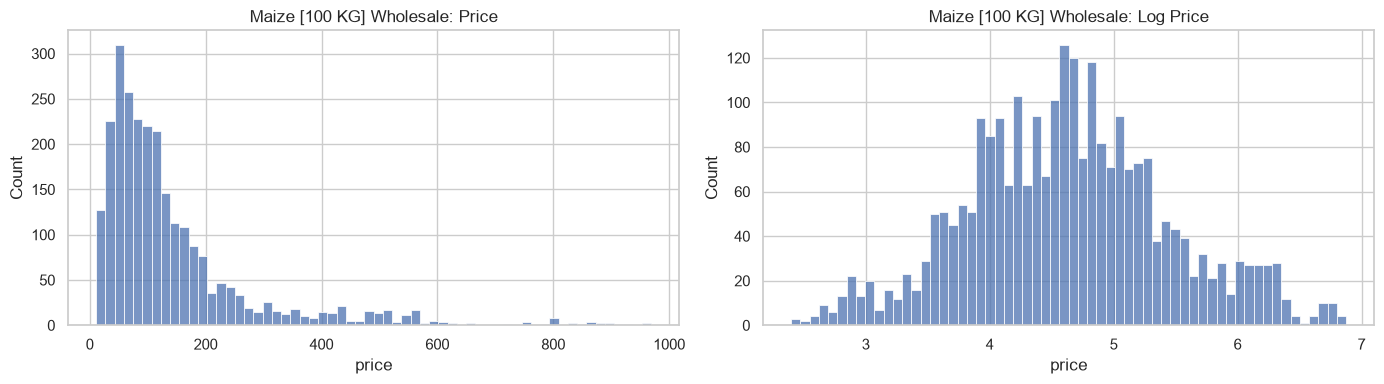

Skewness (price):     2.49
Skewness (log price): 0.14


In [27]:
maize_prices = query(f"""
    SELECT price FROM {RAW_TABLE}
    WHERE commodity = 'Maize' AND unit = '100 KG' AND pricetype = 'Wholesale'
""")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(maize_prices["price"], bins=60, ax=axes[0])
axes[0].set_title("Maize [100 KG] Wholesale: Price")
sns.histplot(np.log(maize_prices["price"]), bins=60, ax=axes[1])
axes[1].set_title("Maize [100 KG] Wholesale: Log Price")
plt.tight_layout()
plt.show()

print(f"Skewness (price):     {maize_prices['price'].skew():.2f}")
print(f"Skewness (log price): {np.log(maize_prices['price']).skew():.2f}")

In [28]:
# Skewness before and after a log transformation, for every series
all_prices = query(f"""
    SELECT pricetype, commodity || ' [' || unit || ']' AS series, price
    FROM {RAW_TABLE}
    WHERE price > 0
""")
all_prices["log_price"] = np.log(all_prices["price"])
skewness_comparison = (
    all_prices.groupby(["pricetype", "series"])
    .agg(skewness_price=("price", "skew"), skewness_log_price=("log_price", "skew"))
    .round(2)
    .sort_values("skewness_price", ascending=False)
)
skewness_comparison

skewness_price  skewness_log_price
pricetype series                                                            
Wholesale Cassava [91 KG]                           7.84                0.78
          Plantains (apentu) [Bunch]                5.04                0.43
Retail    Tomatoes (local) [KG]                     4.76                0.38
          Cowpeas [KG]                              4.73               -0.05
          Plantains (apentu) [KG]                   4.43               -0.43
          Plantains (apem) [KG]                     3.68               -0.22
Wholesale Tomatoes (navrongo) [52 KG]               3.67                0.60
Retail    Onions [KG]                               3.42                0.83
          Peppers (fresh) [KG]                      3.37                0.30
Wholesale Tomatoes (local) [52 KG]                  3.11                1.10
Retail    Tomatoes (navrongo) [KG]                  3.06                0.48
Wholesale Plantains (apem) [Bunch]                  2.89                0.59
          Peppers (dried) [16 KG]                   2.78               -0.45
Retail    Peppers (dried) [KG]                      2.77                0.33
Wholesale Eggs [30 pcs]                             2.77               -0.89
Retail    Soybeans [KG]                             2.76               -0.38
          Gari [KG]                                 2.66                0.46
Wholesale Rice (local) [50 KG]                      2.50                0.21
          Maize [100 KG]                            2.49                0.14
          Soybeans [109 KG]                         2.48               -0.51
Retail    Cassava [KG]                              2.39                0.61
Wholesale Gari [68 KG]                              2.35                0.37
          Peppers (fresh) [20 KG]                   2.20               -0.33
Retail    Fish (mackerel, fresh) [KG]               2.07               -0.30
Wholesale Sorghum [109 KG]                          2.07               -0.06
          Yam (puna) [250 KG]                       1.88                0.06
          Millet [93 KG]                            1.77               -0.09
Retail    Yam (puna) [KG]                           1.76                0.21
          Yam [KG]                                  1.71                0.37
          Rice (local) [KG]                         1.71                0.65
Wholesale Cowpeas (white) [109 KG]                  1.70               -0.21
          Meat (chicken, local) [10 KG]             1.70               -0.44
Retail    Meat (chicken) [KG]                       1.68               -0.20
          Eggplants [KG]                            1.65                0.05
Wholesale Yam [100 Tubers]                          1.61               -0.00
          Maize (yellow) [100 KG]                   1.58               -0.05
          Meat (chicken) [10 KG]                    1.55               -0.24
          Eggplants [27 KG]                         1.38               -0.98
Retail    Sorghum [KG]                              1.31                0.11
Wholesale Yam [250 KG]                              1.27               -0.70
Retail    Maize (yellow) [KG]                       1.22               -0.07
Wholesale Onions [73 KG]                            1.22               -0.85
          Fish (mackerel, fresh) [20 KG]            1.19               -0.16
          Rice (imported) [50 KG]                   1.18               -0.81
Retail    Maize [KG]                                1.14               -0.06
          Millet [KG]                               1.14                0.15
          Rice (imported) [KG]                      1.11               -0.08
Wholesale Rice (local) [100 KG]                     0.69               -0.83
          Rice (paddy) [84 KG]                      0.56               -0.36

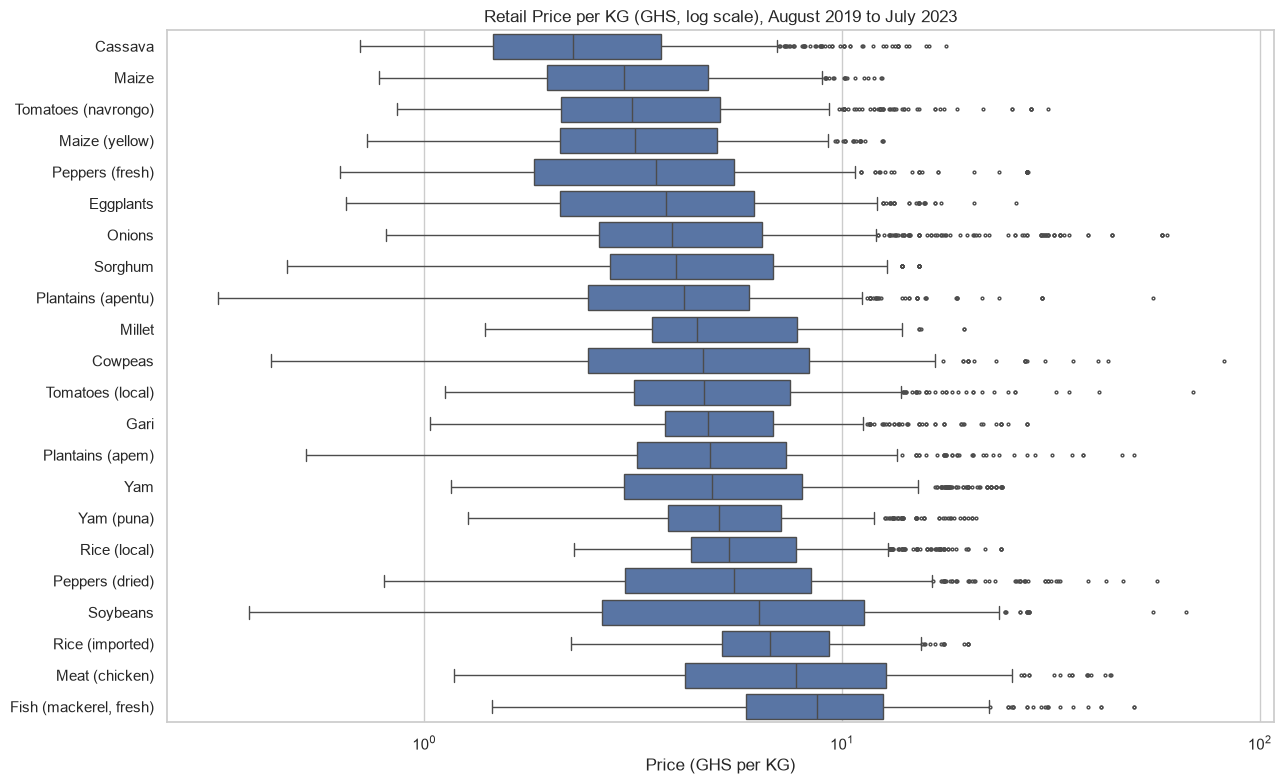

In [29]:
# All retail prices are recorded per KG, so they can be compared across commodities.
retail_prices = query(f"SELECT commodity, price FROM {RAW_TABLE} WHERE pricetype = 'Retail' AND unit = 'KG'")
commodity_order = retail_prices.groupby("commodity")["price"].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 8))
sns.boxplot(data=retail_prices, y="commodity", x="price", order=commodity_order, fliersize=2, ax=ax)
ax.set_xscale("log")
ax.set_title("Retail Price per KG (GHS, log scale), August 2019 to July 2023")
ax.set_xlabel("Price (GHS per KG)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

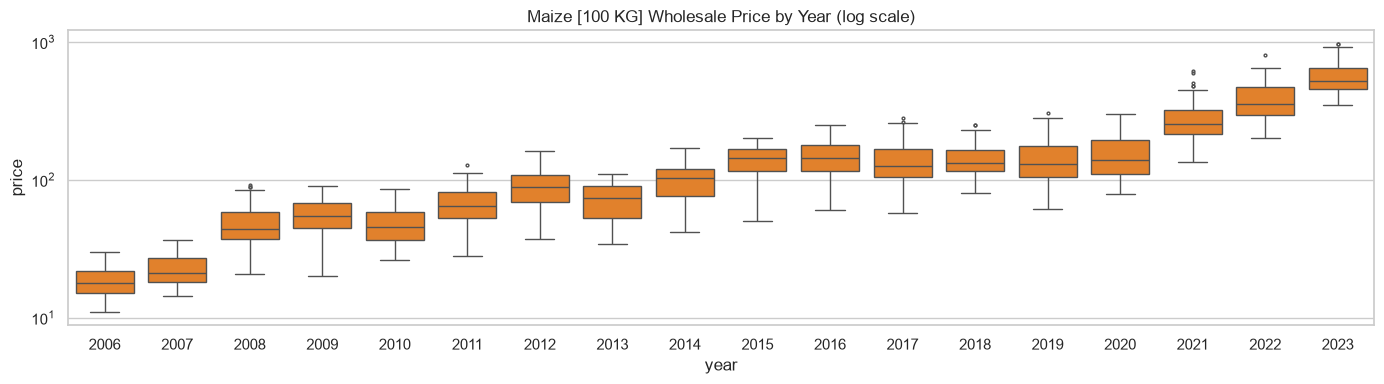

In [30]:
# Price distribution by year. A shifting distribution means the series is non-stationary,
# so statistics pooled across all years should be interpreted with care.
maize_by_year = query(f"""
    SELECT year(date) AS year, price FROM {RAW_TABLE}
    WHERE commodity = 'Maize' AND unit = '100 KG' AND pricetype = 'Wholesale'
""")
fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(data=maize_by_year, x="year", y="price", color="tab:orange", fliersize=2, ax=ax)
ax.set_yscale("log")
ax.set_title("Maize [100 KG] Wholesale Price by Year (log scale)")
plt.tight_layout()
plt.show()

## 8. Visualisation
The charts below use the national monthly **median** across markets for each series. The median is used instead of the mean because it is less affected by errors in individual markets.

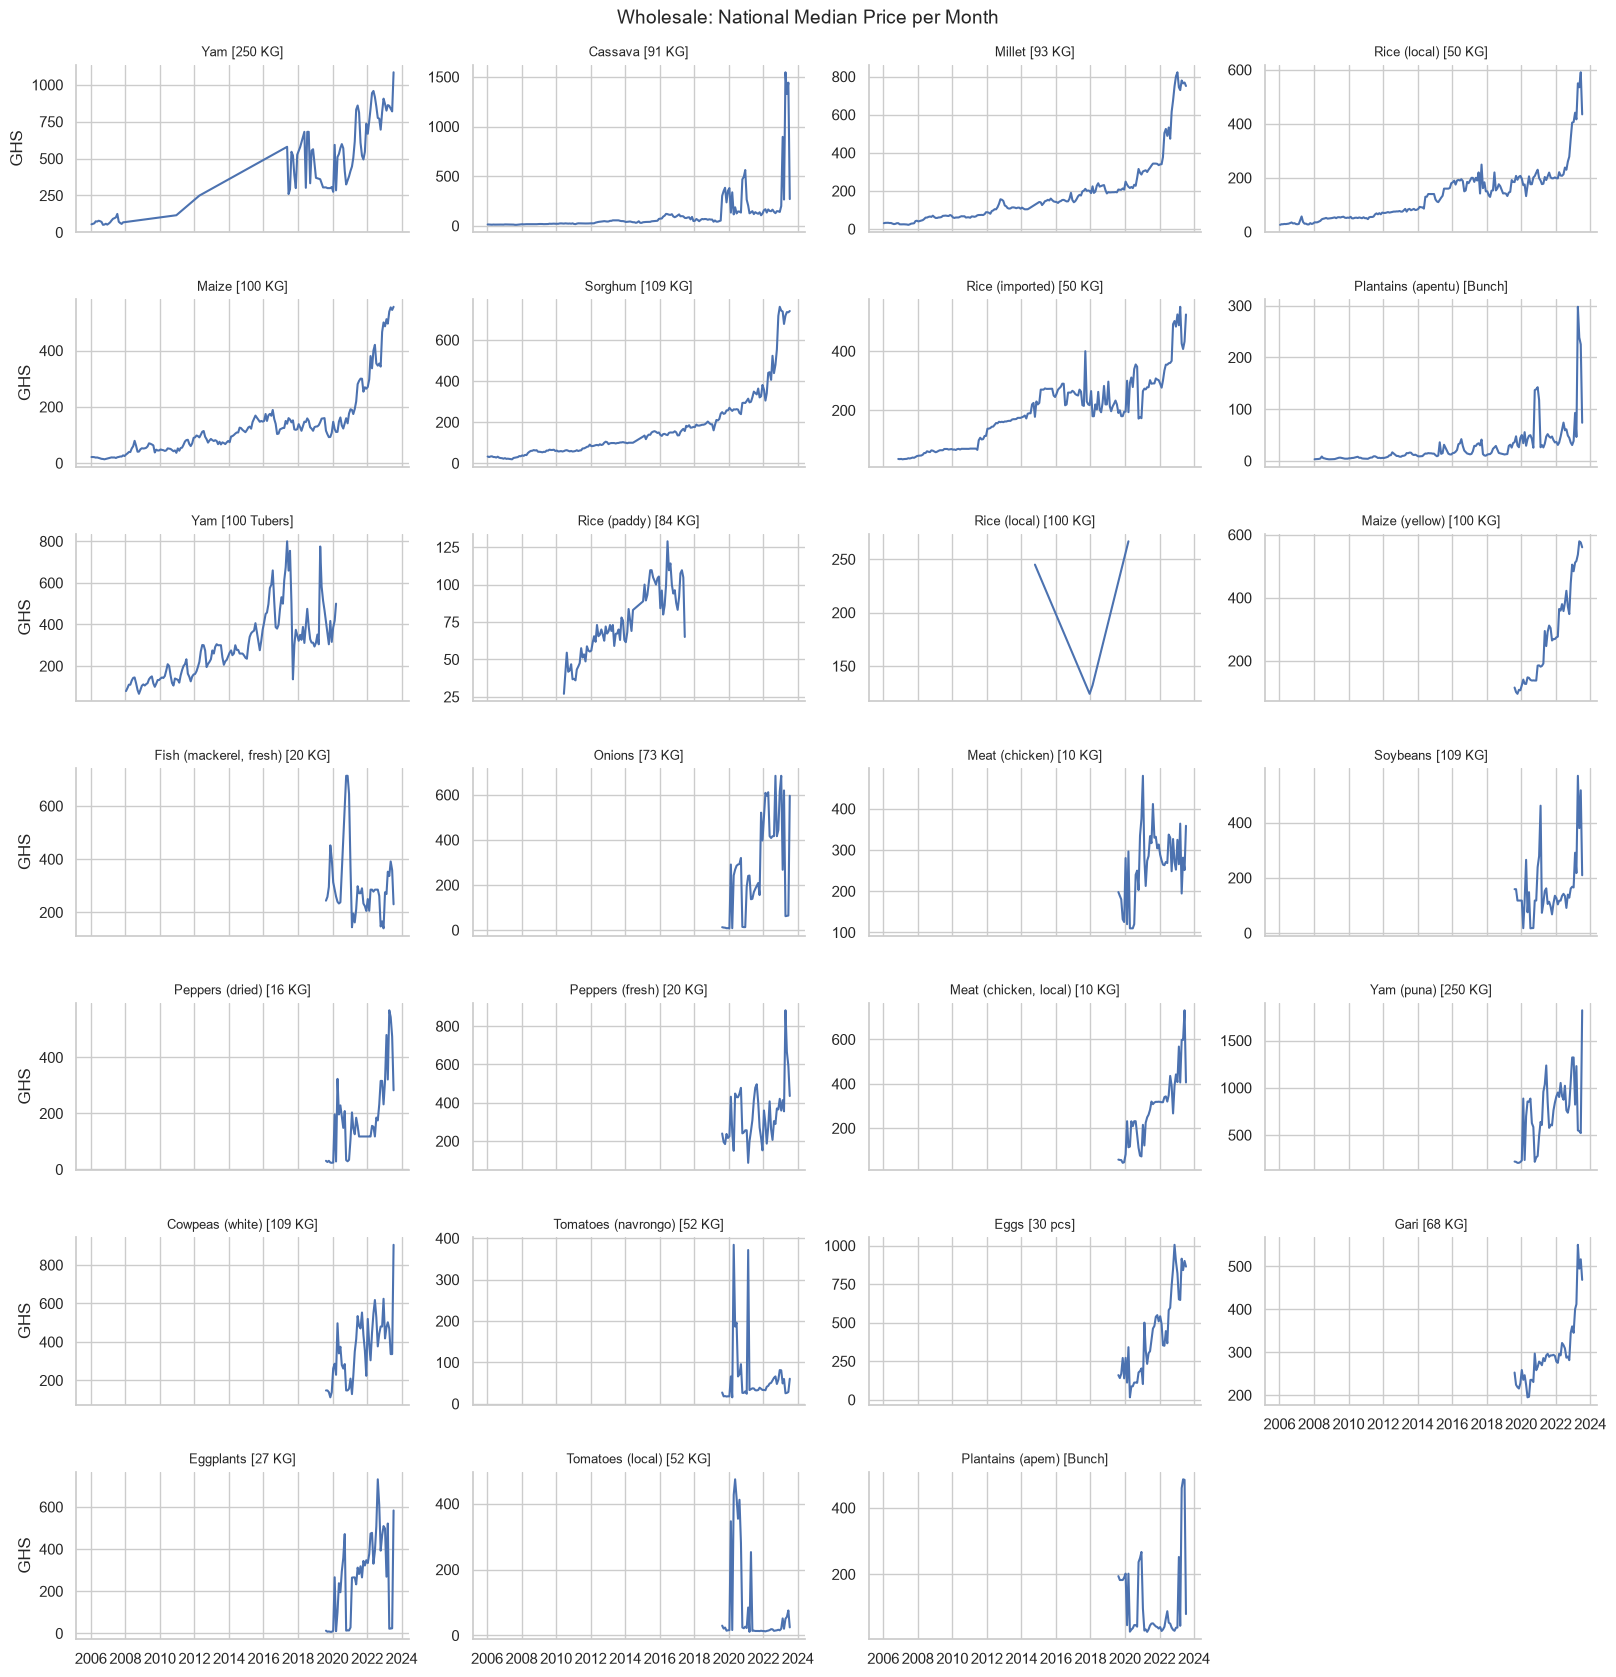

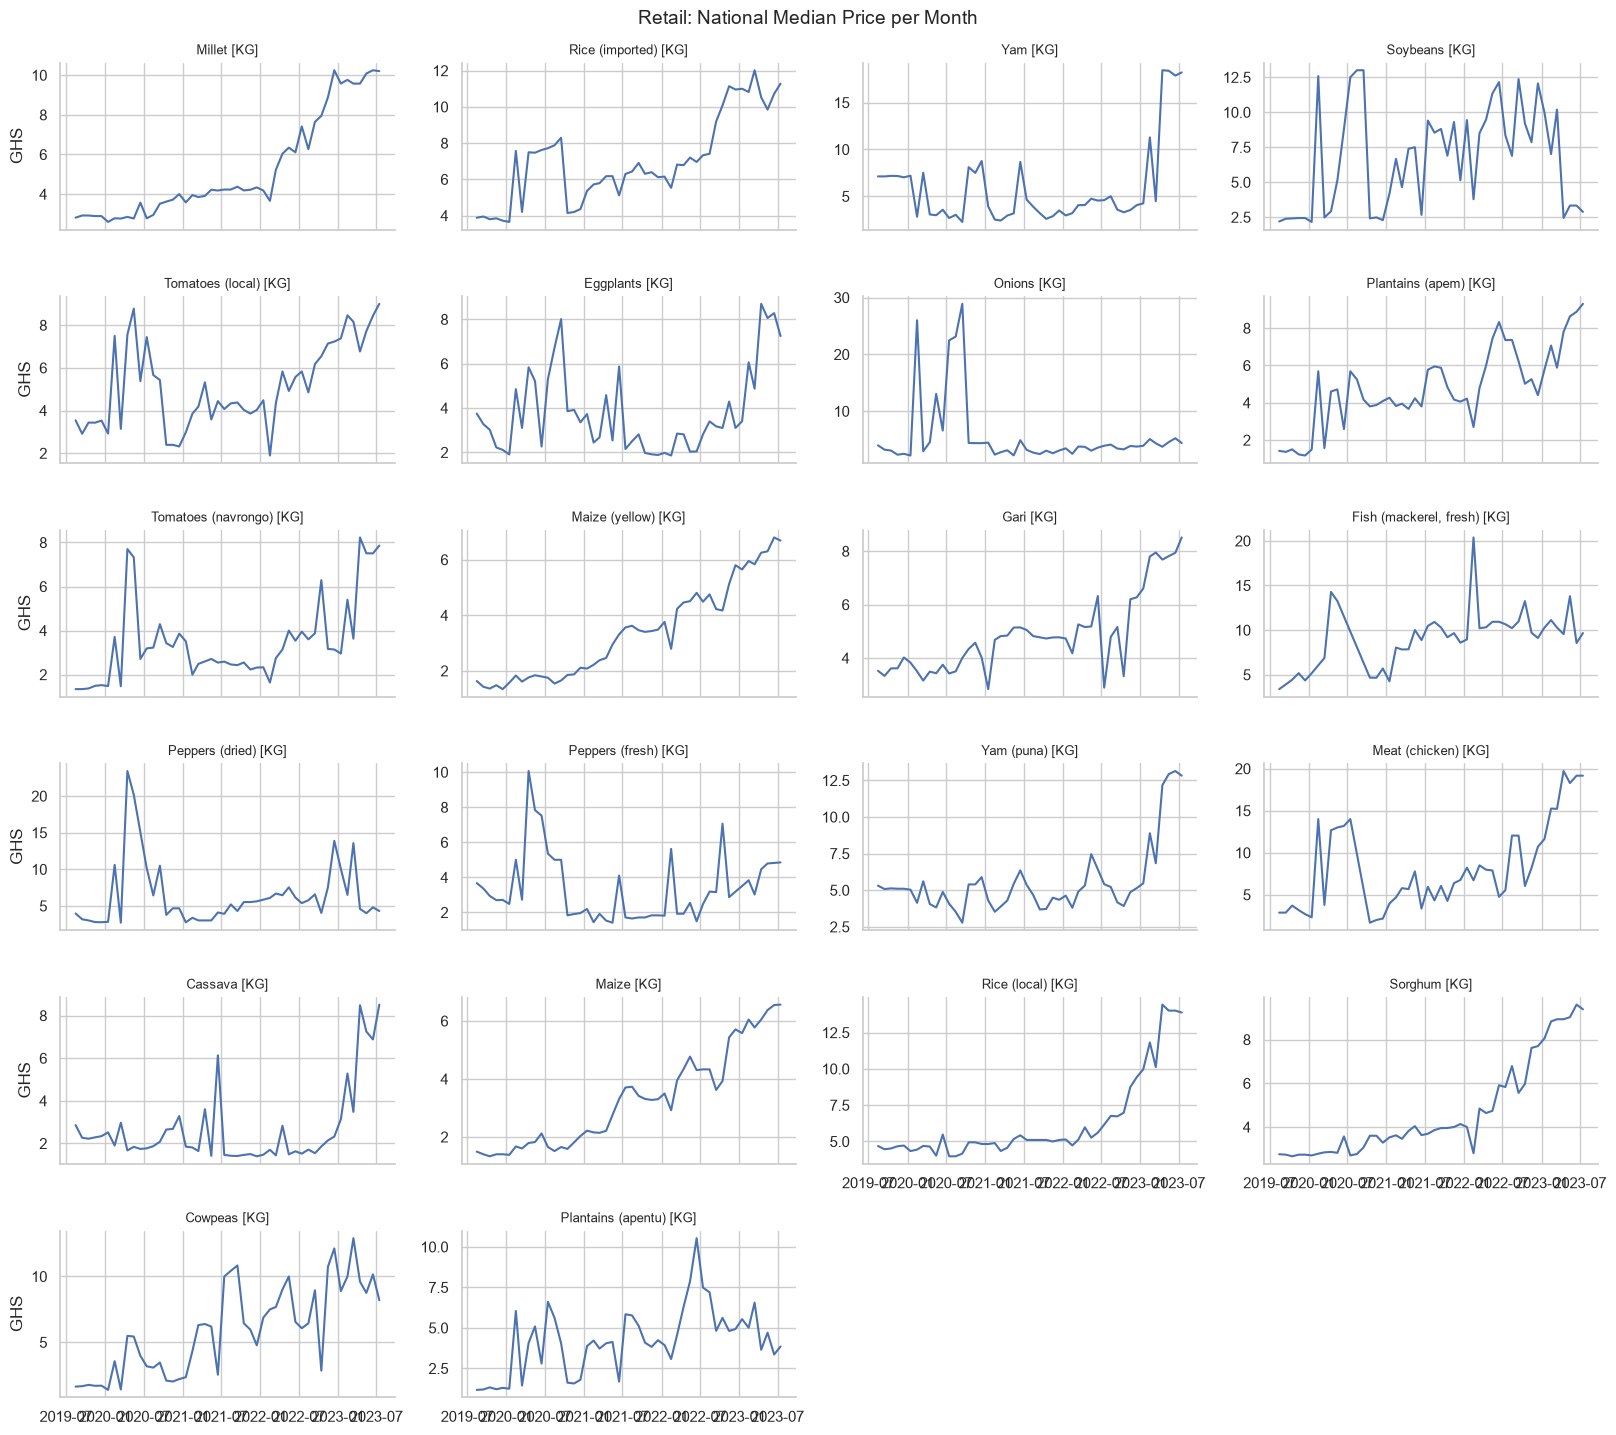

In [31]:
national_monthly = query(f"""
    SELECT
        date, pricetype, commodity, unit,
        commodity || ' [' || unit || ']'   AS series,
        MEDIAN(price)                      AS median_price,
        COUNT(DISTINCT market_id)          AS market_count
    FROM {RAW_TABLE}
    GROUP BY ALL
    ORDER BY date
""")
for price_type in ["Wholesale", "Retail"]:
    subset = national_monthly[national_monthly["pricetype"] == price_type]
    grid = sns.relplot(data=subset, x="date", y="median_price", col="series", col_wrap=4, kind="line",
                       height=2.4, aspect=1.7, facet_kws={"sharey": False, "sharex": True})
    grid.set_titles("{col_name}", size=9)
    grid.set_axis_labels("", "GHS")
    grid.figure.suptitle(f"{price_type}: National Median Price per Month", y=1.01, fontsize=14)
    plt.show()

Long-history wholesale series:
  - Maize [100 KG]
  - Plantains (apentu) [Bunch]
  - Cassava [91 KG]
  - Rice (local) [50 KG]
  - Rice (imported) [50 KG]
  - Yam [100 Tubers]
  - Millet [93 KG]
  - Sorghum [109 KG]


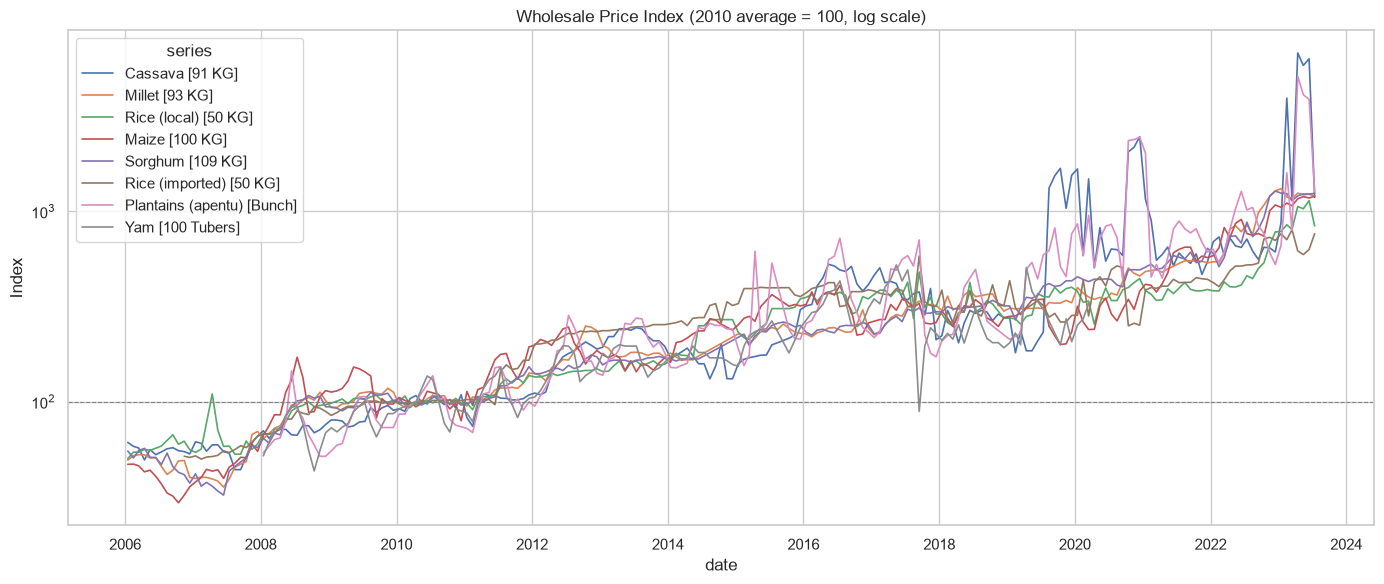

In [32]:
# Wholesale series with a long history: starting before 2010 and with at least 1,000 rows
LONG_HISTORY_SERIES = series_inventory[
    (series_inventory["pricetype"] == "Wholesale")
    & (series_inventory["first_date"] < "2010-01-01")
    & (series_inventory["row_count"] >= 1000)
]["series"].tolist()
print("Long-history wholesale series:")
for name in LONG_HISTORY_SERIES:
    print(f"  - {name}")

# Index each series to its 2010 average (2010 = 100) so that trends can be compared on one chart
long_history = national_monthly[national_monthly["series"].isin(LONG_HISTORY_SERIES)].copy()
base_2010 = long_history[long_history["date"].dt.year == 2010].groupby("series")["median_price"].mean()
long_history["price_index"] = 100 * long_history["median_price"] / long_history["series"].map(base_2010)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=long_history, x="date", y="price_index", hue="series", lw=1.2, ax=ax)
ax.set_yscale("log")
ax.axhline(100, color="grey", ls="--", lw=0.8)
ax.set_title("Wholesale Price Index (2010 average = 100, log scale)")
ax.set_ylabel("Index")
plt.tight_layout()
plt.show()

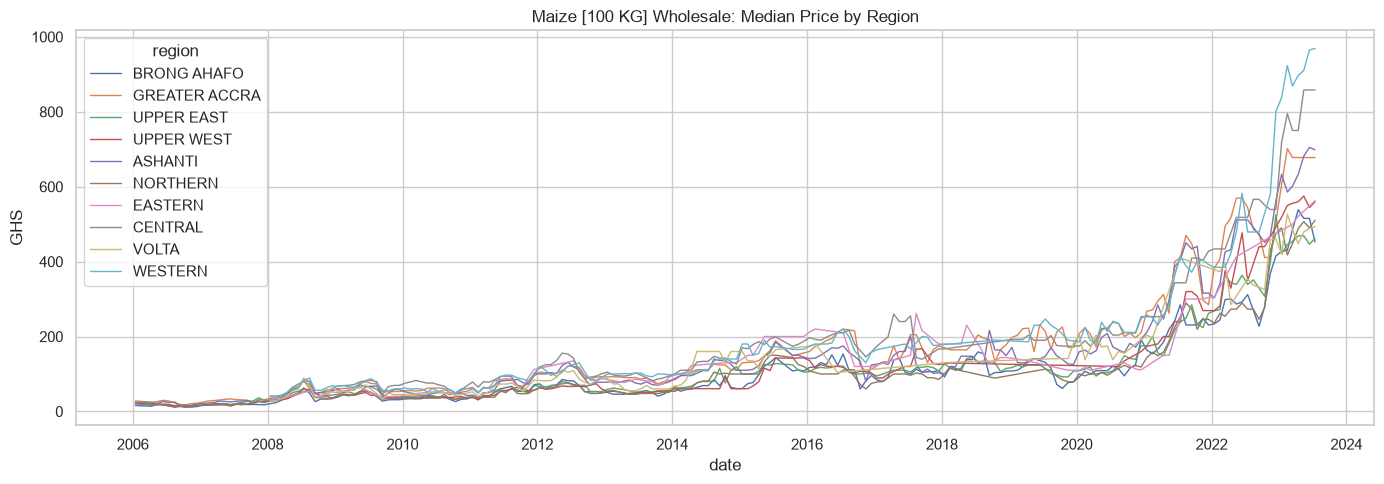

In [33]:
# Regional comparison for maize wholesale prices
maize_by_region = query(f"""
    SELECT date, admin1 AS region, MEDIAN(price) AS median_price
    FROM {RAW_TABLE}
    WHERE commodity = 'Maize' AND unit = '100 KG' AND pricetype = 'Wholesale'
    GROUP BY ALL
    ORDER BY date
""")
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=maize_by_region, x="date", y="median_price", hue="region", lw=1, ax=ax)
ax.set_title("Maize [100 KG] Wholesale: Median Price by Region")
ax.set_ylabel("GHS")
plt.tight_layout()
plt.show()

### 8.1 Seasonality
To isolate seasonal patterns from the long-term trend, each monthly price is divided by a centred 12-month moving average. The result is then averaged for each calendar month across all years. Values show the percentage by which prices in that month are typically above or below the trend.

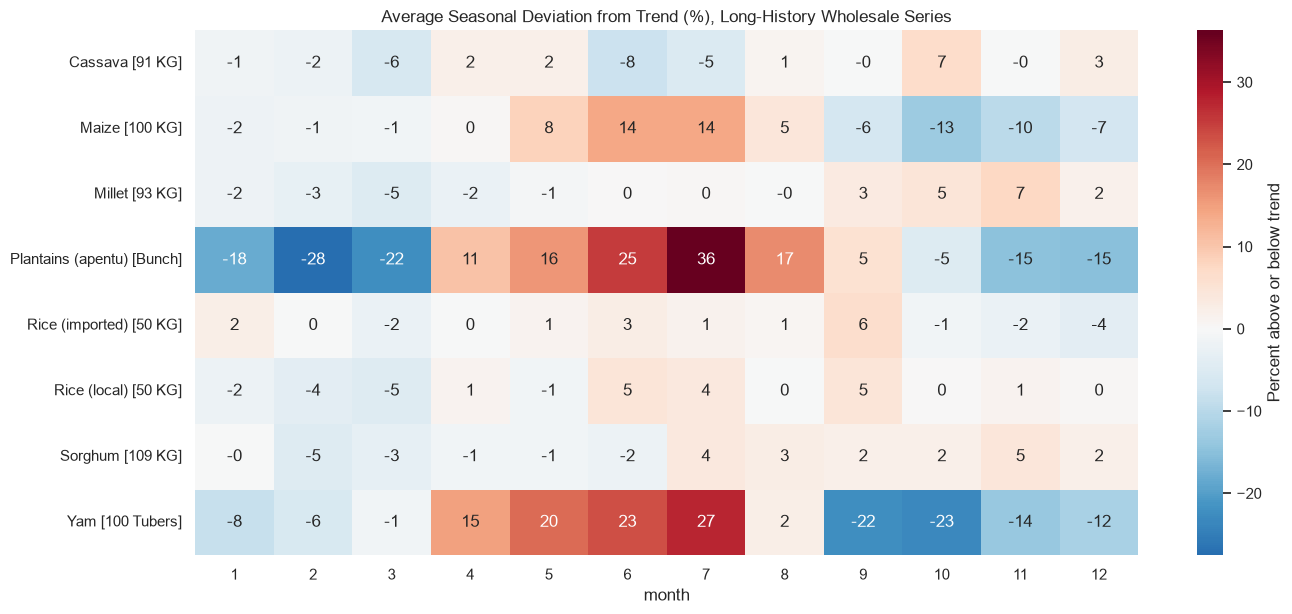

In [34]:
seasonal_frames = []
for series_name, subset in national_monthly[national_monthly["series"].isin(LONG_HISTORY_SERIES)].groupby("series"):
    monthly_price = subset.set_index("date")["median_price"].resample("MS").mean()
    trend = monthly_price.rolling(window=12, center=True, min_periods=9).mean()
    ratio_to_trend = (monthly_price / trend).dropna()
    seasonal_frames.append(pd.DataFrame({
        "series": series_name,
        "month": ratio_to_trend.index.month,
        "percent_vs_trend": 100 * (ratio_to_trend.values - 1),
    }))
seasonal_deviation = pd.concat(seasonal_frames)
seasonal_profile = seasonal_deviation.groupby(["series", "month"])["percent_vs_trend"].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 0.6 * len(seasonal_profile) + 1.5))
sns.heatmap(seasonal_profile, cmap="RdBu_r", center=0, annot=True, fmt=".0f", ax=ax,
            cbar_kws={"label": "Percent above or below trend"})
ax.set_title("Average Seasonal Deviation from Trend (%), Long-History Wholesale Series")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [35]:
# Consistency of the seasonal pattern: standard deviation of the monthly deviation across years.
# Lower values indicate a more reliable seasonal pattern.
seasonal_deviation.groupby(["series", "month"])["percent_vs_trend"].std().unstack().round(1)

month,1,2,3,4,5,6,7,8,9,10,11,12
series,,,,,,,,,,,,
Cassava [91 KG],23.6,23.5,21.9,41.7,30.0,22.6,21.0,21.3,27.2,30.8,31.1,39.6
Maize [100 KG],8.6,7.5,8.6,7.4,9.0,10.4,17.8,12.4,12.2,9.2,8.3,9.1
Millet [93 KG],8.7,6.3,3.9,6.6,5.6,7.3,6.5,8.0,6.0,9.0,9.7,9.5
Plantains (apentu) [Bunch],32.7,14.5,22.2,54.4,32.3,31.8,30.3,20.3,33.2,33.3,37.0,42.6
Rice (imported) [50 KG],10.9,10.1,10.2,6.8,8.0,8.4,10.9,12.6,17.6,13.5,10.8,9.9
Rice (local) [50 KG],6.1,8.0,8.6,21.8,8.6,11.4,7.2,11.2,13.7,7.1,6.3,8.7
Sorghum [109 KG],5.6,8.3,4.0,6.0,5.1,7.5,5.1,7.6,7.4,4.9,6.5,7.6
Yam [100 Tubers],9.7,8.9,10.6,23.1,15.1,10.1,13.5,7.7,19.1,11.3,7.0,6.9


## 9. Outlier Detection
Outliers are identified here but not removed. The treatment of outliers will be decided in Phase 2.

Two methods are used. Both work on the logarithm of price, so they are not affected by differences in units.

1. **Cross-market comparison:** each price is compared with the prices of the same series in other markets during the same month, using a robust z-score based on the median and the median absolute deviation (MAD). Comparing within the same month prevents inflation from being mistaken for outliers.
2. **Month-over-month change:** each price is compared with the previous month's price in the same market. A **spike** is a large change that is immediately reversed in the following month (for example, a price that triples and then returns to its previous level). Spikes often indicate data entry or unit errors rather than genuine market movements.

In [36]:
ROBUST_Z_THRESHOLD = 3.5   # a commonly used cut-off for robust z-scores
MIN_MARKETS_PER_MONTH = 5  # minimum number of markets needed for a meaningful comparison

cross_market_scores = query(f"""
    WITH prices AS (
        SELECT *, ln(price) AS log_price FROM {RAW_TABLE} WHERE price > 0
    ),
    monthly_stats AS (
        SELECT date, commodity, unit, pricetype,
               COUNT(*)          AS market_count,
               MEDIAN(log_price) AS median_log_price,
               MAD(log_price)    AS mad_log_price
        FROM prices
        GROUP BY ALL
    )
    SELECT
        p.date, p.market, p.admin1 AS region, p.commodity, p.unit, p.pricetype, p.priceflag,
        p.price,
        ROUND(exp(s.median_log_price), 2) AS monthly_median_price,
        s.market_count,
        (p.log_price - s.median_log_price) / (1.4826 * NULLIF(s.mad_log_price, 0)) AS robust_z
    FROM prices p
    JOIN monthly_stats s USING (date, commodity, unit, pricetype)
    WHERE s.market_count >= {MIN_MARKETS_PER_MONTH}
""")
cross_market_scores["ratio_to_median"] = (cross_market_scores["price"] / cross_market_scores["monthly_median_price"]).round(2)
cross_market_outliers = cross_market_scores[cross_market_scores["robust_z"].abs() > ROBUST_Z_THRESHOLD]

share = 100 * len(cross_market_outliers) / len(cross_market_scores)
print(f"Cross-market outliers (|robust z| > {ROBUST_Z_THRESHOLD}): "
      f"{len(cross_market_outliers):,} of {len(cross_market_scores):,} rows ({share:.2f}%)")
display(cross_market_outliers.groupby(["pricetype", "commodity", "unit"]).size()
        .sort_values(ascending=False).rename("outlier_count").head(15))
cross_market_outliers.reindex(cross_market_outliers["robust_z"].abs().sort_values(ascending=False).index).head(20)

Cross-market outliers (|robust z| > 3.5): 873 of 36,911 rows (2.37%)


pricetype  commodity           unit      
Wholesale  Rice (imported)     50 KG         76
           Sorghum             109 KG        67
           Yam                 100 Tubers    51
           Millet              93 KG         45
Retail     Gari                KG            44
Wholesale  Rice (local)        50 KG         36
           Plantains (apentu)  Bunch         33
           Tomatoes (local)    52 KG         29
           Gari                68 KG         28
Retail     Plantains (apem)    KG            27
           Millet              KG            23
Wholesale  Yam                 250 KG        23
           Eggs                30 pcs        22
           Yam (puna)          250 KG        21
Retail     Soybeans            KG            18
Name: outlier_count, dtype: int64

,date,market,region,commodity,unit,pricetype,priceflag,price,monthly_median_price,market_count,robust_z,ratio_to_median
10519,2022-08-15,Accra,GREATER ACCRA,Eggplants,27 KG,Wholesale,aggregate,156.60,731.19,5,-75.246239,0.21
10426,2022-08-15,Techiman,BRONG AHAFO,Eggplants,27 KG,Wholesale,aggregate,323.62,731.19,5,-39.801632,0.44
3156,2014-02-15,Tamale,NORTHERN,Sorghum,109 KG,Wholesale,actual,80.00,97.50,5,-32.457200,0.82
14306,2008-08-15,Accra,GREATER ACCRA,Sorghum,109 KG,Wholesale,actual,72.50,61.00,5,28.366035,1.19
6271,2020-07-15,Tamale,NORTHERN,Yam (puna),250 KG,Wholesale,aggregate,416.67,886.35,7,-25.491751,0.47
18479,2020-02-15,Tamale,NORTHERN,Yam (puna),250 KG,Wholesale,aggregate,416.67,886.35,7,-25.491751,0.47
3233,2014-03-15,Accra,GREATER ACCRA,Sorghum,109 KG,Wholesale,actual,173.00,100.00,6,24.275275,1.73
18414,2020-02-15,Accra,GREATER ACCRA,Yam (puna),250 KG,Wholesale,aggregate,442.37,886.35,7,-23.470422,0.50
6198,2020-07-15,Accra,GREATER ACCRA,Yam (puna),250 KG,Wholesale,aggregate,442.37,886.35,7,-23.470422,0.50
1106,2012-03-15,Bolga,UPPER EAST,Rice (imported),50 KG,Wholesale,actual,75.00,140.00,6,-23.151696,0.54


Consecutive month-over-month changes:   32,259
Changes larger than a doubling/halving: 2,375
Spikes (large change then reversal):    714


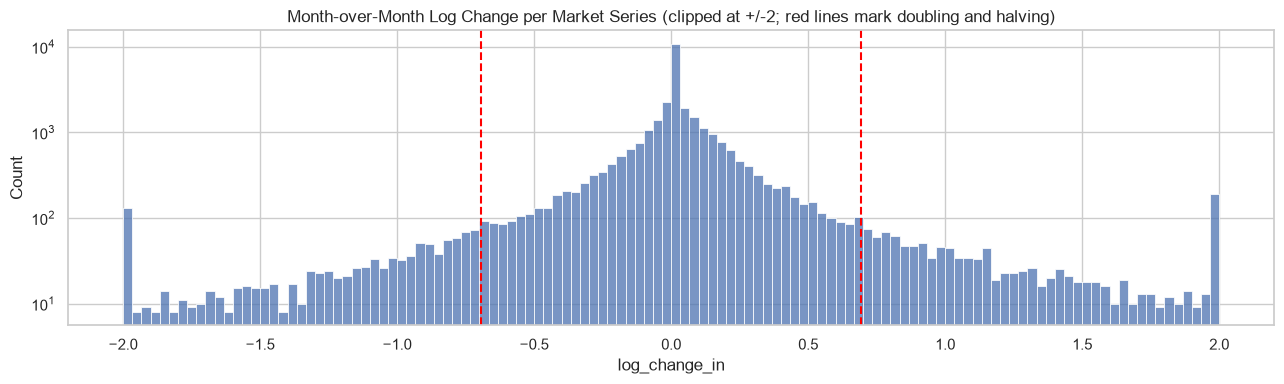

,date,market,commodity,unit,pricetype,previous_price,price,next_price
37713,2008-07-15,Wa,Yam,100 Tubers,Wholesale,155.00,17.00,133.30
16214,2008-07-15,Sekondi/Takoradi,Plantains (apentu),Bunch,Wholesale,6.60,1.90,5.58
21395,2009-05-15,Ho,Cassava,91 KG,Wholesale,25.25,12.60,33.30
33208,2009-05-15,Ejura,Cassava,91 KG,Wholesale,8.00,30.00,8.30
5625,2009-09-15,Ejura,Maize,100 KG,Wholesale,53.60,20.00,42.50
34693,2011-06-15,Sunyani,Cassava,91 KG,Wholesale,25.00,83.75,18.50
21234,2011-06-15,Sunyani,Yam,100 Tubers,Wholesale,185.00,20.00,230.00
21235,2011-07-15,Sunyani,Yam,100 Tubers,Wholesale,20.00,230.00,100.00
9085,2012-07-15,Bolga,Yam,100 Tubers,Wholesale,144.00,20.00,180.00
28561,2012-08-15,Wa,Cassava,91 KG,Wholesale,45.00,95.20,47.50


In [37]:
LARGE_CHANGE = np.log(2)   # a doubling or halving of price

monthly_changes = query(f"""
    WITH one_price_per_key AS (
        -- Ensures one price per market, series and month (uses the median if a key is duplicated)
        SELECT market_id, ANY_VALUE(market) AS market, commodity, unit, pricetype, date,
               MEDIAN(price) AS price
        FROM {RAW_TABLE}
        WHERE price > 0
        GROUP BY market_id, commodity, unit, pricetype, date
    ),
    with_neighbours AS (
        SELECT *,
               LAG(price)  OVER w AS previous_price,
               LAG(date)   OVER w AS previous_date,
               LEAD(price) OVER w AS next_price,
               LEAD(date)  OVER w AS next_date
        FROM one_price_per_key
        WINDOW w AS (PARTITION BY market_id, commodity, unit, pricetype ORDER BY date)
    )
    SELECT *,
           ln(price / previous_price)                AS log_change_in,
           ln(next_price / price)                    AS log_change_out,
           date_diff('month', previous_date, date)   AS months_since_previous,
           date_diff('month', date, next_date)       AS months_to_next
    FROM with_neighbours
""")

consecutive = monthly_changes[monthly_changes["months_since_previous"] == 1]
large_changes = consecutive[consecutive["log_change_in"].abs() > LARGE_CHANGE]
spikes = monthly_changes[
    (monthly_changes["months_since_previous"] == 1)
    & (monthly_changes["months_to_next"] == 1)
    & (monthly_changes["log_change_in"].abs() > LARGE_CHANGE)
    & (monthly_changes["log_change_out"].abs() > LARGE_CHANGE)
    & (np.sign(monthly_changes["log_change_in"]) != np.sign(monthly_changes["log_change_out"]))
]
print(f"Consecutive month-over-month changes:   {len(consecutive):,}")
print(f"Changes larger than a doubling/halving: {len(large_changes):,}")
print(f"Spikes (large change then reversal):    {len(spikes):,}")

fig, ax = plt.subplots(figsize=(13, 4))
sns.histplot(consecutive["log_change_in"].clip(-2, 2), bins=120, ax=ax)
ax.axvline(LARGE_CHANGE, color="red", ls="--")
ax.axvline(-LARGE_CHANGE, color="red", ls="--")
ax.set_yscale("log")
ax.set_title("Month-over-Month Log Change per Market Series (clipped at +/-2; red lines mark doubling and halving)")
plt.tight_layout()
plt.show()

spikes[["date", "market", "commodity", "unit", "pricetype", "previous_price", "price", "next_price"]].sort_values("date").head(25)

market  commodity        unit        pricetype
Accra   Sorghum          109 KG      Wholesale    44
        Millet           93 KG       Wholesale    30
Bolga   Rice (imported)  50 KG       Wholesale    28
Tamale  Yam              100 Tubers  Wholesale    20
Name: flag_count, dtype: int64

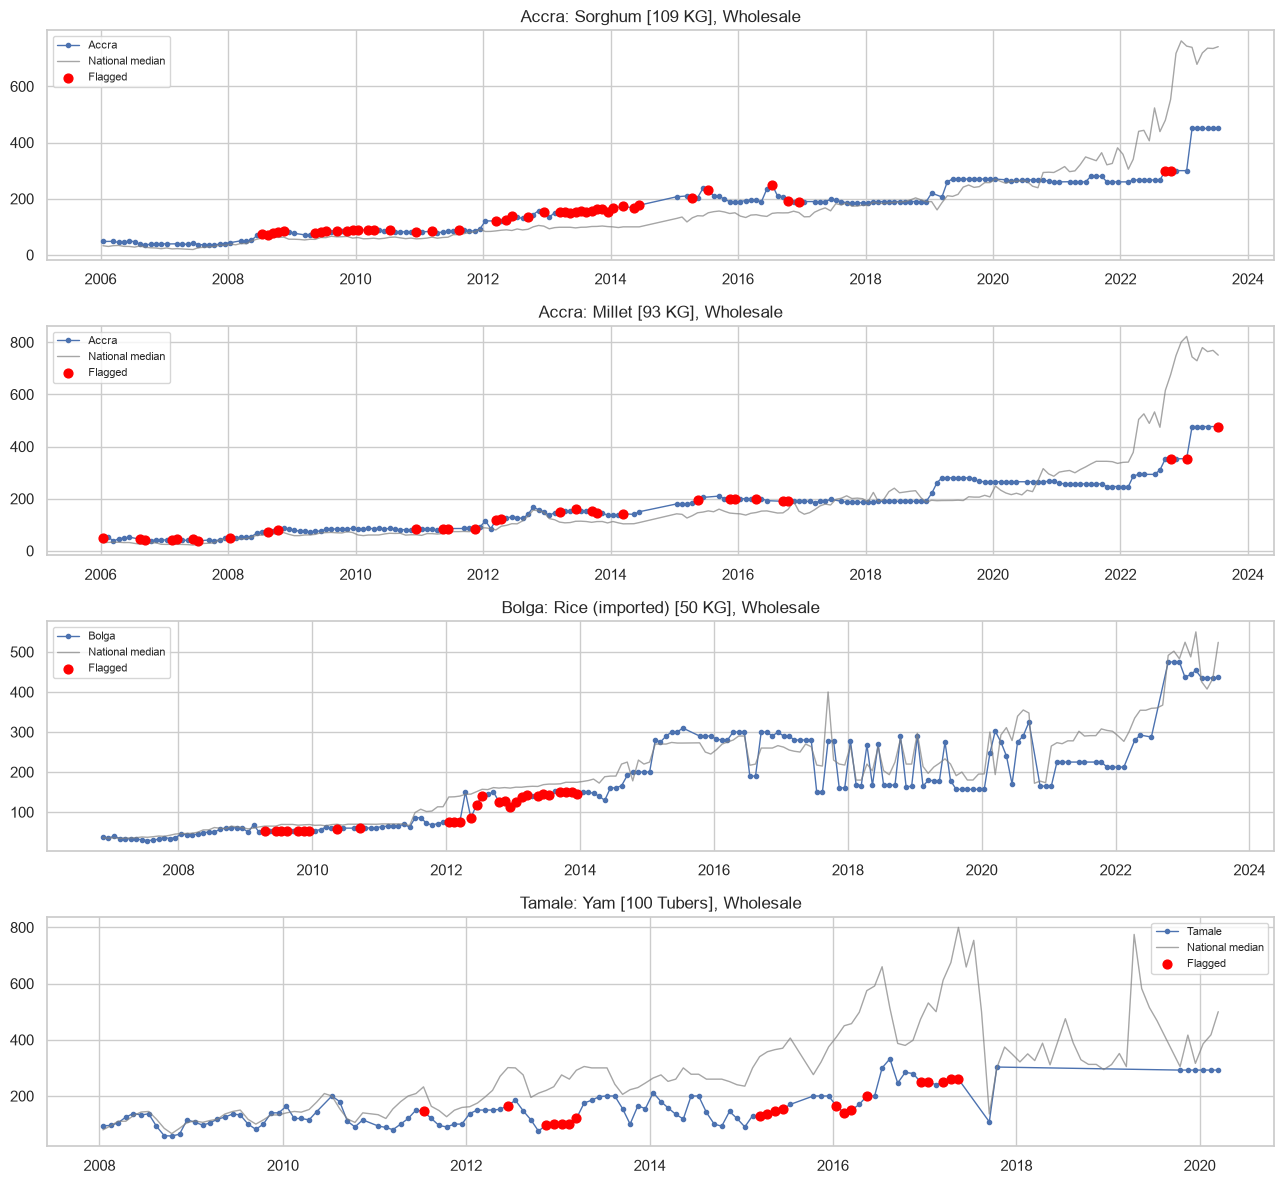

In [38]:
# Visual inspection of the four market series with the most flagged observations
all_flags = pd.concat([
    spikes[["market", "commodity", "unit", "pricetype", "date"]].assign(method="Spike"),
    cross_market_outliers[["market", "commodity", "unit", "pricetype", "date"]].assign(method="Cross-market"),
])

if all_flags.empty:
    print("No observations were flagged.")
else:
    most_flagged = (all_flags.groupby(["market", "commodity", "unit", "pricetype"]).size()
                    .sort_values(ascending=False).head(4))
    display(most_flagged.rename("flag_count"))

    fig, axes = plt.subplots(len(most_flagged), 1, figsize=(13, 3 * len(most_flagged)), squeeze=False)
    for ax, (key, _) in zip(axes[:, 0], most_flagged.items()):
        market, commodity, unit, price_type = key
        is_series = lambda df: ((df["commodity"] == commodity) & (df["unit"] == unit) & (df["pricetype"] == price_type))
        market_prices = monthly_changes[is_series(monthly_changes) & (monthly_changes["market"] == market)]
        national = national_monthly[is_series(national_monthly)]
        flagged_dates = all_flags[is_series(all_flags) & (all_flags["market"] == market)]["date"]
        flagged_points = market_prices[market_prices["date"].isin(flagged_dates)]

        ax.plot(market_prices["date"], market_prices["price"], marker=".", lw=1, label=market)
        ax.plot(national["date"], national["median_price"], color="grey", lw=1, alpha=0.7, label="National median")
        ax.scatter(flagged_points["date"], flagged_points["price"], color="red", s=40, zorder=5, label="Flagged")
        ax.set_title(f"{market}: {commodity} [{unit}], {price_type}")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Correlation Analysis
### 10.1 Redundant Columns

In [39]:
query(f"""
    SELECT
        pricetype,
        ROUND(corr(price, usdprice), 4)          AS corr_price_usdprice,
        ROUND(corr(ln(price), ln(usdprice)), 4)  AS corr_log_price_log_usdprice
    FROM {RAW_TABLE}
    WHERE price > 0 AND usdprice > 0
    GROUP BY 1
""")

,pricetype,corr_price_usdprice,corr_log_price_log_usdprice
0,Wholesale,0.7259,0.8119
1,Retail,0.9011,0.9138


`usdprice` is derived from `price` using the exchange rate. It contains no additional information about market prices, only exchange-rate movements. Similarly, if Section 4.4 confirms one-to-one relationships, `market_id`, `commodity_id`, `latitude` and `longitude` duplicate information already held in `market` and `commodity`.

### 10.2 Co-movement Between Commodities
Correlations between price **levels** are inflated by the shared inflation trend: almost all prices rise over time, so they appear strongly correlated. Correlations between **monthly changes** remove this effect and give a more reliable measure of whether commodities move together.

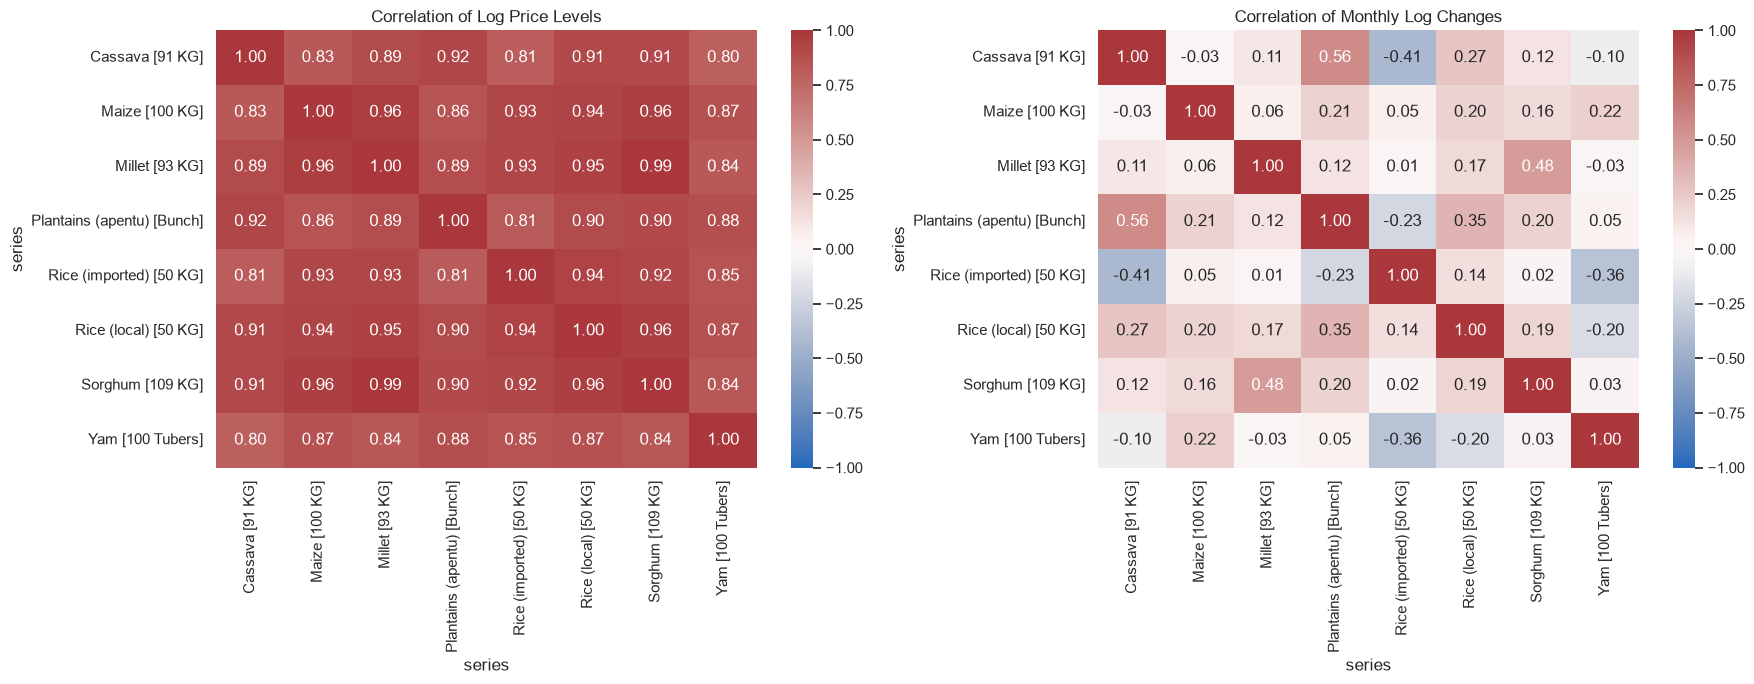

In [40]:
long_history_wide = (
    national_monthly[national_monthly["series"].isin(LONG_HISTORY_SERIES)]
    .pivot_table(index="date", columns="series", values="median_price")
    .resample("MS").mean()
)
log_prices_wide = np.log(long_history_wide)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(log_prices_wide.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlation of Log Price Levels")
sns.heatmap(log_prices_wide.diff().corr(), annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlation of Monthly Log Changes")
plt.tight_layout()
plt.show()

### 10.3 Wholesale and Retail Prices
For commodities recorded at both price types (from August 2019), this section tests whether wholesale and retail prices move together.

In [41]:
# Use the most frequently recorded wholesale unit for each commodity
main_wholesale_unit = (
    series_inventory[series_inventory["pricetype"] == "Wholesale"]
    .sort_values("row_count", ascending=False)
    .drop_duplicates("commodity")[["commodity", "unit"]]
)

comparison_rows = []
for _, row in main_wholesale_unit.iterrows():
    wholesale = national_monthly[(national_monthly["pricetype"] == "Wholesale")
                                 & (national_monthly["commodity"] == row["commodity"])
                                 & (national_monthly["unit"] == row["unit"])]
    retail = national_monthly[(national_monthly["pricetype"] == "Retail")
                              & (national_monthly["commodity"] == row["commodity"])
                              & (national_monthly["unit"] == "KG")]
    if retail.empty:
        continue
    paired = pd.concat({"wholesale": wholesale.set_index("date")["median_price"],
                        "retail": retail.set_index("date")["median_price"]}, axis=1)
    paired = paired[paired.index >= "2019-08-01"].resample("MS").mean().dropna()
    monthly_log_change = np.log(paired).diff().dropna()
    if len(monthly_log_change) >= 12:
        comparison_rows.append({
            "commodity": row["commodity"],
            "wholesale_unit": row["unit"],
            "months": len(paired),
            "corr_levels": np.log(paired).corr().iloc[0, 1],
            "corr_monthly_changes": monthly_log_change.corr().iloc[0, 1],
        })

wholesale_retail_corr = pd.DataFrame(comparison_rows).sort_values("corr_monthly_changes", ascending=False).round(2)
wholesale_retail_corr

C:\Users\qwarm\AppData\Local\Temp\ipykernel_13728\3192116654.py:18: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  paired = pd.concat({"wholesale": wholesale.set_index("date")["median_price"],


,commodity,wholesale_unit,months,corr_levels,corr_monthly_changes
4,Rice (imported),50 KG,48,0.96,0.84
13,Tomatoes (local),52 KG,48,0.43,0.66
17,Onions,73 KG,48,0.21,0.63
19,Peppers (dried),16 KG,47,0.51,0.63
7,Maize (yellow),100 KG,47,0.99,0.61
3,Rice (local),50 KG,48,0.96,0.45
0,Maize,100 KG,48,0.98,0.42
2,Cassava,91 KG,48,0.74,0.36
5,Millet,93 KG,48,0.99,0.32
11,Tomatoes (navrongo),52 KG,47,0.41,0.29


### 10.4 Geographic Price Differences
This section tests whether prices vary systematically from south to north. For each wholesale series, every market's price is divided by the median price across all markets in the same month, which gives a unit-free **relative price**. The median relative price for each market is then correlated with the market's latitude (higher latitude means further north).

,commodity,unit,market_count,spearman_latitude_vs_relative_price
19,Sorghum,109 KG,18,-0.94
10,Millet,93 KG,18,-0.94
23,Yam,100 Tubers,15,-0.82
1,Cowpeas (white),109 KG,17,-0.79
3,Eggs,30 pcs,18,-0.72
18,Rice (local),50 KG,20,-0.69
7,Maize (yellow),100 KG,17,-0.69
6,Maize,100 KG,44,-0.59
24,Yam,250 KG,18,-0.59
20,Soybeans,109 KG,18,-0.53


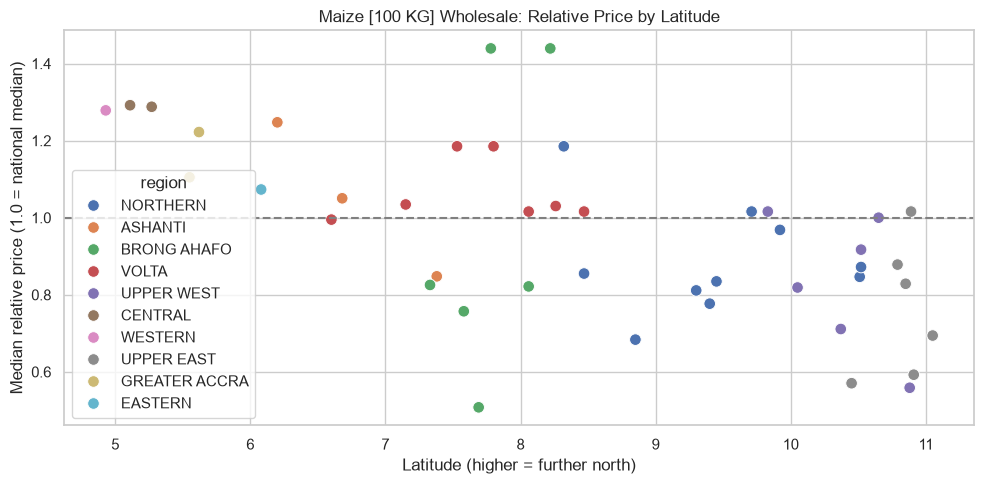

In [42]:
relative_prices = query(f"""
    WITH wholesale AS (
        SELECT * FROM {RAW_TABLE} WHERE pricetype = 'Wholesale' AND price > 0
    ),
    monthly_median AS (
        SELECT commodity, unit, date, MEDIAN(price) AS median_price, COUNT(*) AS market_count
        FROM wholesale
        GROUP BY ALL
    ),
    relative AS (
        SELECT w.*, w.price / m.median_price AS relative_price
        FROM wholesale w
        JOIN monthly_median m USING (commodity, unit, date)
        WHERE m.market_count >= 5
    )
    SELECT
        market_id,
        ANY_VALUE(market)     AS market,
        ANY_VALUE(admin1)     AS region,
        ANY_VALUE(latitude)   AS latitude,
        commodity, unit,
        MEDIAN(relative_price) AS median_relative_price,
        COUNT(*)               AS row_count
    FROM relative
    GROUP BY market_id, commodity, unit
""")

latitude_rows = []
for (commodity, unit), subset in relative_prices.groupby(["commodity", "unit"]):
    if subset["market_id"].nunique() >= 8:
        latitude_rows.append({
            "commodity": commodity,
            "unit": unit,
            "market_count": subset["market_id"].nunique(),
            "spearman_latitude_vs_relative_price":
                subset["latitude"].corr(subset["median_relative_price"], method="spearman"),
        })
latitude_corr = pd.DataFrame(latitude_rows).sort_values("spearman_latitude_vs_relative_price").round(2)
display(latitude_corr)

maize_relative = relative_prices[(relative_prices["commodity"] == "Maize") & (relative_prices["unit"] == "100 KG")]
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=maize_relative, x="latitude", y="median_relative_price", hue="region", s=70, ax=ax)
ax.axhline(1, color="grey", ls="--")
ax.set_title("Maize [100 KG] Wholesale: Relative Price by Latitude")
ax.set_xlabel("Latitude (higher = further north)")
ax.set_ylabel("Median relative price (1.0 = national median)")
plt.tight_layout()
plt.show()

## 11. Summary of Findings
### 11.1 Key Figures
The table below collects the main figures calculated in this notebook.

In [43]:
summary = overview.iloc[0]
wholesale_count = int((series_inventory["pricetype"] == "Wholesale").sum())
retail_count = int((series_inventory["pricetype"] == "Retail").sum())
consistency_failures = [f"{name} ({count})" for name, count in consistency_results.items() if count]

key_figures = {
    "Total rows": f"{summary['row_count']:,}",
    "Period covered": f"{summary['first_date']:%B %Y} to {summary['last_date']:%B %Y}",
    "Months with data": f"{summary['months_with_data']} of {summary['months_in_period']}",
    "Number of series": f"{len(series_inventory)} ({wholesale_count} wholesale, {retail_count} retail)",
    "First retail observation": f"{series_inventory.loc[series_inventory['pricetype'] == 'Retail', 'first_date'].min():%B %Y}",
    "Long-history wholesale series": f"{len(LONG_HISTORY_SERIES)}",
    "Missing values (all columns)": f"{int(missing_values['null_count'].sum()):,}",
    "Exact duplicate rows": f"{int(exact_duplicates.iloc[0, 0]):,}",
    "Duplicate keys": f"{len(duplicate_keys):,} ({conflicting_count:,} with conflicting prices)",
    "Identifier consistency failures": ", ".join(consistency_failures) if consistency_failures else "None",
    "Rows with inconsistent USD conversion (above 2%)": f"{len(inconsistent_usd_rows):,}",
    "Market series meeting modelling criteria": (
        f"{int(market_series['meets_criteria'].sum()):,} of {len(market_series):,} "
        f"(at least {MIN_MONTHS} months, {MIN_COMPLETENESS:.0%} complete, gaps of {MAX_GAP_MONTHS} months or less)"
    ),
    "Cross-market outliers": f"{len(cross_market_outliers):,}",
    "Month-over-month spikes": f"{len(spikes):,}",
}
pd.Series(key_figures, name="Value").to_frame()

,Value
Total rows,"37,765"
Period covered,January 2006 to July 2023
Months with data,211 of 211
Number of series,"49 (27 wholesale, 22 retail)"
First retail observation,August 2019
Long-history wholesale series,8
Missing values (all columns),0
Exact duplicate rows,0
Duplicate keys,0 (0 with conflicting prices)
Identifier consistency failures,None


### 11.2 Findings
*To be completed after reviewing the outputs above.*

| No. | Finding | Section | Implication for Phase 2 |
|---|---|---|---|
| 1 | | | |
| 2 | | | |
| 3 | | | |
| 4 | | | |
| 5 | | | |

### 11.3 Decisions Required for Phase 2
- [ ] **Target variable:** Which price type and unit will be modelled, and at what level (market, region or national)?
- [ ] **Scope:** Which commodities and markets have sufficient coverage? (Section 5.1)
- [ ] **Duplicate keys:** How should repeated records be resolved? (Section 4.2)
- [ ] **Price flag:** Should all records be kept, or should `actual` prices be preferred? (Section 4.3)
- [ ] **Outliers:** Should flagged observations be kept, capped or removed? (Section 9)
- [ ] **Units:** Should wholesale prices be converted to a per-KG basis, or should each series be modelled in its original unit? (Section 2.1)
- [ ] **Inflation:** Should models use nominal prices, log prices or inflation-adjusted prices? (Sections 6 and 8)
- [ ] **Redundant columns:** Should `usdprice`, the identifier columns and the coordinates be removed? (Section 10.1)

In [44]:
con.close()
print("Database connection closed.")

Database connection closed.
